# Imports

In [2]:
import os
import sys
import json
import pickle
import datetime
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import mlflow
import optuna
from tqdm.notebook import tqdm;
import sklearn.pipeline as skpipe
from sklearn.model_selection import train_test_split

# making src/ importable from the notebook
sys.path.insert(0, os.path.abspath(".."))

from src.datalib import build_engine
from src.datalib.features import extract_features
from src.datalib.transforms import LocationEncoder, FillNaTransformer
from src.model_utils import ModelKeeper

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ---- Scientific plot style ----
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 140,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "0.3",
    "axes.linewidth": 0.8,
    "grid.color": "0.88",
    "grid.linewidth": 0.5,
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.1,
})
PALETTE = sns.color_palette("colorblind")
from src.training.learners import (
    SLearnerWrapper, XLearnerWrapper, RLearnerWrapper, UpliftModelWrapper,
)
from src.training.metrics import qini_coefficient, uplift_at_k, TrialLogger

print("Done")

Done


## Data Loading
Using the same `build_engine()` that we do in the main flow â€” ensuring consistency between training and inference.

In [2]:
# building the engine
engine = build_engine(os.path.abspath("../data"))

# loading the tables themselves
customers = engine.get_table("customers")
receipts = engine.get_table("receipts")
campaigns = engine.get_table("campaigns")

# Sanity check - we got the data
print("customers:", customers.shape)
print("receipts:", receipts.shape)
print("campaigns:", campaigns.shape)

customers: (2000000, 4)
receipts: (31741769, 5)
campaigns: (500000, 5)


## EDA: Basic Statistics

In [3]:
print("=== customers ===")
display(customers.describe())
display(customers["location"].value_counts())

print("\n=== receipts ===")
display(receipts.describe())

print("\n=== campaigns ===")
display(campaigns.describe())
print("Target group distribution:")
display(campaigns["target_group_flag"].value_counts(normalize=True))

# IMPORTANT: All campaign customers have target_group_flag = 1
# This means the campaigns table only contains TREATMENT group.
# Control group = all customers NOT in campaigns table.
print(f"\nAll campaign entries have target_group_flag=1: {(campaigns['target_group_flag'] == 1).all()}")
print(f"Campaign customers: {len(campaigns)}, Total customers: {len(customers)}")
print(f"Control group (not in campaigns): {len(customers) - len(campaigns)}")

=== customers ===


,Unnamed: 0,customer_id,age
count,2.000000e+06,2.000000e+06,2.000000e+06
mean,9.999995e+05,9.999995e+05,4.450815e+01
std,5.773504e+05,5.773504e+05,1.443533e+01
min,0.000000e+00,0.000000e+00,2.000000e+01
25%,4.999998e+05,4.999998e+05,3.200000e+01
50%,9.999995e+05,9.999995e+05,4.500000e+01
75%,1.499999e+06,1.499999e+06,5.700000e+01
max,1.999999e+06,1.999999e+06,6.900000e+01


location
Amsterdam     300918
Vienna        300689
Brussels      299988
Oslo          299775
Stockholm     299456
Copenhagen    299075
Prague        200099
Name: count, dtype: int64


=== receipts ===


,customer_id,date,purchase_amt,discount,purchase_sum
count,3.174177e+07,3.174177e+07,3.174177e+07,3.174177e+07,3.174177e+07
mean,9.996451e+05,1.244958e+02,1.646350e+01,2.854598e-01,1.317080e+03
std,5.775345e+05,7.213806e+01,9.322197e+00,3.367032e+00,7.457758e+02
min,0.000000e+00,0.000000e+00,1.024931e+00,0.000000e+00,8.199448e+01
25%,4.990100e+05,6.200000e+01,9.504848e+00,0.000000e+00,7.603878e+02
50%,9.990780e+05,1.240000e+02,1.478924e+01,0.000000e+00,1.183139e+03
75%,1.499913e+06,1.870000e+02,2.197335e+01,0.000000e+00,1.757868e+03
max,1.999999e+06,2.490000e+02,7.728300e+01,4.000000e+01,6.182640e+03



=== campaigns ===


,Unnamed: 0,customer_id,n_offer_days,date,target_group_flag
count,500000.000000,500000.000000,500000.0,500000.0,500000.0
mean,249999.500000,249999.500000,7.0,102.0,1.0
std,144337.711635,144337.711635,0.0,0.0,0.0
min,0.000000,0.000000,7.0,102.0,1.0
25%,124999.750000,124999.750000,7.0,102.0,1.0
50%,249999.500000,249999.500000,7.0,102.0,1.0
75%,374999.250000,374999.250000,7.0,102.0,1.0
max,499999.000000,499999.000000,7.0,102.0,1.0


Target group distribution:


target_group_flag
1    1.0
Name: proportion, dtype: float64


All campaign entries have target_group_flag=1: True
Campaign customers: 500000, Total customers: 2000000
Control group (not in campaigns): 1500000


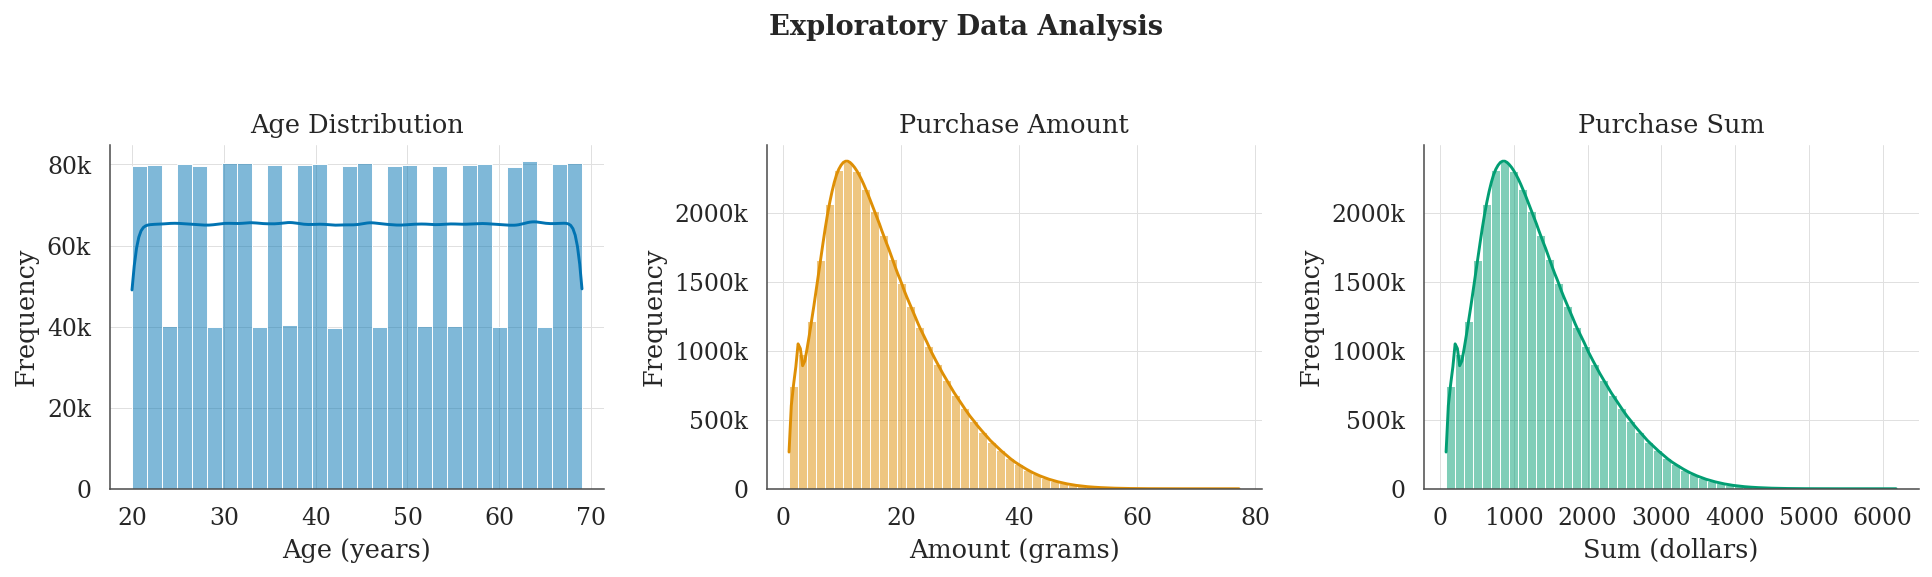

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(customers["age"], bins=30, kde=True, color=PALETTE[0], edgecolor="white",
             linewidth=0.5, ax=axes[0])
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Frequency")

sns.histplot(receipts["purchase_amt"], bins=50, kde=True, color=PALETTE[1], edgecolor="white",
             linewidth=0.5, ax=axes[1])
axes[1].set_title("Purchase Amount")
axes[1].set_xlabel("Amount (grams)")
axes[1].set_ylabel("Frequency")

sns.histplot(receipts["purchase_sum"], bins=50, kde=True, color=PALETTE[2], edgecolor="white",
             linewidth=0.5, ax=axes[2])
axes[2].set_title("Purchase Sum")
axes[2].set_xlabel("Sum (dollars)")
axes[2].set_ylabel("Frequency")

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k" if x >= 1000 else f"{x:.0f}"))
    sns.despine(ax=ax)

plt.suptitle("Exploratory Data Analysis", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## Construct the Target Variable

**Key insight**: ALL entries in `campaigns` have `target_group_flag=1`. This means the campaigns table only records customers who **received** the offer (treatment group). Everyone else is control (target_group_flag=0).

We build the full training set by:
1. Taking ALL customers
2. Marking campaign participants as treatment (1), everyone else as control (0)
3. Computing post-campaign profit for everyone

In [5]:
COST_PER_GRAM = 52
PRICE_PER_GRAM = 80
MARGIN_PER_GRAM = PRICE_PER_GRAM - COST_PER_GRAM  # 28 dollars/gram
CONTACT_COST = 1            # communication cost per selected customer
OFFER_DAYS = 7            # actual campaign window (n_offer_days = 7)

# Campaign date is an INTEGER day-number (not a calendar date).
# Do NOT call pd.to_datetime() on it -- that converts integers to nanosecond
# timestamps, making 30 calendar days >> 249 nanoseconds (the full date range),
# so the window filter captures everything regardless of OFFER_DAYS value.
campaign_date = int(campaigns["date"].min())
window_start  = campaign_date
window_end    = campaign_date + OFFER_DAYS   # exclusive upper bound
print(f"Campaign date (day-number): {campaign_date}")
print(f"Post-campaign window: [{window_start}, {window_end})")

# receipts["date"] is also an integer column -- plain integer comparison
post_receipts = receipts[
    (receipts["date"] >= window_start) & (receipts["date"] < window_end)
]
print(f"Post-campaign receipts: {len(post_receipts):,}")
print(f"Discount > 0 in window: {(post_receipts['discount'] > 0).sum():,}")

# Per-customer aggregation: grams, revenue, AND discount actually given
client_revenue = (
    post_receipts
    .groupby("customer_id")
    .agg(
        total_purchased_grams=("purchase_amt", "sum"),
        total_revenue=("purchase_sum", "sum"),
        total_discount=("discount", "sum"),    # 40 dollars per treated transaction
    )
    .reset_index()
)

# Build full training set: ALL 2M customers
# Treatment = in campaigns table (target_group_flag = 1)
# Control   = everyone else      (target_group_flag = 0)
campaign_ids = set(campaigns["customer_id"].unique())

train_data = customers[["customer_id"]].copy()
train_data["target_group_flag"] = train_data["customer_id"].isin(campaign_ids).astype(int)
train_data = train_data.merge(client_revenue, on="customer_id", how="left").fillna(0)

# TARGET VARIABLE: bake ALL campaign costs into the target so the model
# directly optimises net profit. Qini then aligns with the business metric.
#
#   treated:  target_profit = grams * MARGIN  -  discount_given  -  CONTACT_COST
#   control:  target_profit = grams * MARGIN
#
# CATE = E[target_profit | T=1, X] - E[target_profit | T=0, X]
#      = MARGIN * delta_grams  -  E[discount | T=1, X]  -  CONTACT_COST
#
# At serving time: select where CATE > 0.  No extra cost formula needed.
train_data["target_profit"] = (
    train_data["total_purchased_grams"] * MARGIN_PER_GRAM
    - train_data["total_discount"]
    - train_data["target_group_flag"] * CONTACT_COST
)

print(f"\nTrain data shape: {train_data.shape}")
print(f"Treatment split:  {train_data['target_group_flag'].value_counts().to_dict()}")
print(f"Treatment rate:   {train_data['target_group_flag'].mean():.2%}")
mask_t = train_data["target_group_flag"] == 1
mask_c = train_data["target_group_flag"] == 0
print(f"Mean target_profit -- treated: {train_data.loc[mask_t,'target_profit'].mean():.4f}")
print(f"Mean target_profit -- control: {train_data.loc[mask_c,'target_profit'].mean():.4f}")
print(f"Overall ATE (sanity):          {train_data.loc[mask_t,'target_profit'].mean() - train_data.loc[mask_c,'target_profit'].mean():.4f}")


Campaign date (day-number): 102
Post-campaign window: [102, 109)
Post-campaign receipts: 913,572
Discount > 0 in window: 226,525

Train data shape: (2000000, 6)
Treatment split:  {0: 1500000, 1: 500000}
Treatment rate:   25.00%
Mean target_profit -- treated: 202.6667
Mean target_profit -- control: 204.6514
Overall ATE (sanity):          -1.9847


## Feature Extraction

Using the same calcers as in the serving config (DoW, avg city cheque, loyalty, multi-window aggregates, etc.).

In [6]:
# Features computed on data BEFORE the campaign start -- no leakage.
# FEATURE_DATE is a plain integer day-number (same coordinate as receipts/campaigns).
FEATURE_DATE = campaign_date - 1
print("Feature date (day-number):", FEATURE_DATE)

extract_config = [
    # Multi-window receipt aggregates (7 windows)
    {"name": "receipts_agg",     "args": {"delta": 7,   "date_to": FEATURE_DATE}},
    {"name": "receipts_agg",     "args": {"delta": 15,  "date_to": FEATURE_DATE}},
    {"name": "receipts_agg",     "args": {"delta": 30,  "date_to": FEATURE_DATE}},
    {"name": "receipts_agg",     "args": {"delta": 60,  "date_to": FEATURE_DATE}},
    {"name": "receipts_agg",     "args": {"delta": 90,  "date_to": FEATURE_DATE}},
    {"name": "receipts_agg",     "args": {"delta": 180, "date_to": FEATURE_DATE}},
    {"name": "receipts_agg",     "args": {"delta": 365, "date_to": FEATURE_DATE}},
    # Recency
    {"name": "recency_global",   "args": {"date_to": FEATURE_DATE}},
    # Multiple purchase-trend ratios
    {"name": "purchase_trend",   "args": {"delta_short": 7,  "delta_long": 30,  "date_to": FEATURE_DATE}},
    {"name": "purchase_trend",   "args": {"delta_short": 15, "delta_long": 60,  "date_to": FEATURE_DATE}},
    {"name": "purchase_trend",   "args": {"delta_short": 30, "delta_long": 120, "date_to": FEATURE_DATE}},
    {"name": "purchase_trend",   "args": {"delta_short": 30, "delta_long": 365, "date_to": FEATURE_DATE}},
    {"name": "purchase_trend",   "args": {"delta_short": 90, "delta_long": 365, "date_to": FEATURE_DATE}},
    # Demographics + campaign history
    {"name": "demographics",     "args": {}},
    {"name": "campaign_history", "args": {"date_to": FEATURE_DATE}},
    # Behavioural features
    {"name": "day_of_week",      "args": {"date_to": FEATURE_DATE}},
    {"name": "avg_city_cheque",  "args": {"date_to": FEATURE_DATE}},
    {"name": "loyalty",          "args": {"date_to": FEATURE_DATE}},
]

raw_features = extract_features(engine, extract_config)
print("Raw features shape:", raw_features.shape)
raw_features.head()


Feature date (day-number): 101
Raw features shape: (2000000, 119)


,customer_id,txn_count__7d,purchase_amt_sum__7d,purchase_amt_mean__7d,purchase_amt_max__7d,purchase_amt_min__7d,purchase_amt_std__7d,purchase_sum_sum__7d,purchase_sum_mean__7d,purchase_sum_max__7d,...,mode_dow,weekend_purchase_share,customer_avg_cheque,city_avg_cheque,cheque_vs_city,n_unique_days,lifespan_days,purchase_frequency,spend_per_day,loyalty_score
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.000000,814.890617,1357.562844,0.600260,11.0,90.0,0.122222,814.890617,0.551327
1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,0.166667,942.007275,1058.470799,0.889970,6.0,66.0,0.090909,942.007275,0.382245
2,2,2.0,39.13365,19.566825,34.363092,4.770558,20.925082,3130.691978,1565.345989,2749.047367,...,2.0,0.125000,2013.546857,1058.470799,1.902317,8.0,90.0,0.088889,2013.546857,0.400965
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,0.125000,2083.343606,1355.910958,1.536490,8.0,72.0,0.111111,2083.343606,0.476718
4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,0.000000,1646.439397,1058.931197,1.554812,2.0,20.0,0.100000,1646.439397,0.304452


## Merge Features with Target + Transform

In [7]:
data = train_data.merge(raw_features, on="customer_id", how="inner")
print("Merged data shape:", data.shape)

# sklearn Pipeline for preprocessing
transform_pipeline = skpipe.Pipeline([
    ("fill_na", FillNaTransformer(fill_value=0.0)),
    ("encode_location", LocationEncoder(prefix="loc")),
])

data = transform_pipeline.fit_transform(data)
print("Transformed data shape:", data.shape)

Merged data shape: (2000000, 124)
Transformed data shape: (2000000, 130)


## Define Feature / Treatment / Target Columns

In [8]:
non_feature_cols = [
    "customer_id",
    "target_group_flag",
    "total_purchased_grams", "total_revenue", "total_discount",
    "target_profit",         # this IS the target -- keep out of X
]

cols_features = [c for c in data.columns if c not in non_feature_cols]
col_treatment = "target_group_flag"
col_target    = "target_profit"   # profit with costs baked in (dollars)

print(f"Features: {len(cols_features)}")
print(cols_features)
print(f"Target column : {col_target}")
print(f"Treatment col : {col_treatment}")
print(f"Target stats  -- mean={data[col_target].mean():.4f}  std={data[col_target].std():.4f}")


Features: 124
['txn_count__7d', 'purchase_amt_sum__7d', 'purchase_amt_mean__7d', 'purchase_amt_max__7d', 'purchase_amt_min__7d', 'purchase_amt_std__7d', 'purchase_sum_sum__7d', 'purchase_sum_mean__7d', 'purchase_sum_max__7d', 'purchase_sum_min__7d', 'purchase_sum_std__7d', 'mean_time_interval__7d', 'recency__7d', 'txn_count__15d', 'purchase_amt_sum__15d', 'purchase_amt_mean__15d', 'purchase_amt_max__15d', 'purchase_amt_min__15d', 'purchase_amt_std__15d', 'purchase_sum_sum__15d', 'purchase_sum_mean__15d', 'purchase_sum_max__15d', 'purchase_sum_min__15d', 'purchase_sum_std__15d', 'mean_time_interval__15d', 'recency__15d', 'txn_count__30d', 'purchase_amt_sum__30d', 'purchase_amt_mean__30d', 'purchase_amt_max__30d', 'purchase_amt_min__30d', 'purchase_amt_std__30d', 'purchase_sum_sum__30d', 'purchase_sum_mean__30d', 'purchase_sum_max__30d', 'purchase_sum_min__30d', 'purchase_sum_std__30d', 'mean_time_interval__30d', 'recency__30d', 'txn_count__60d', 'purchase_amt_sum__60d', 'purchase_amt_me

## Train/Val Split

In [9]:
fit_idx, val_idx = train_test_split(data.index, test_size=0.3, random_state=69)
print(f"Train: {len(fit_idx)}, Val: {len(val_idx)}")
print(f"Treatment rate (train): {data.loc[fit_idx, col_treatment].mean():.2%}")
print(f"Treatment rate (val):   {data.loc[val_idx, col_treatment].mean():.2%}")

Train: 1400000, Val: 600000
Treatment rate (train): 24.98%
Treatment rate (val):   25.04%


## MLflow Setup + Evaluation Helpers

In [10]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")  # or "mlruns" for file-based
mlflow.set_experiment("smart-reach-training")

RANDOM_STATE = 69
N_TRIALS_FAST = 80    # LightGBM, XGBoost (fast learners)
N_TRIALS_MEDIUM = 60  # CatBoost, Uplift Tree, X-Learner, R-Learner
N_TRIALS_SLOW = 40    # Uplift Random Forest (expensive)

print(f"Optuna trials: fast={N_TRIALS_FAST}, medium={N_TRIALS_MEDIUM}, slow={N_TRIALS_SLOW}")

Optuna trials: fast=80, medium=60, slow=40


## Model Wrappers, Metrics & Data Preparation

Wrapper classes give every model the same `predict(X) -> (n, 1)` interface so they work with `ModelKeeper`. The **Qini coefficient** is the primary Optuna objective — it measures how well the model ranks customers by true uplift.

In [11]:
# Wrapper classes and metrics live in src/training/
# (SLearnerWrapper, XLearnerWrapper, RLearnerWrapper, UpliftModelWrapper,
#  qini_coefficient, uplift_at_k, TrialLogger)

# ---- Prepare numpy arrays for Optuna loops ---------------------------
X_train_full = data.loc[fit_idx, cols_features].values.astype(np.float32)
y_train_full = data.loc[fit_idx, col_target].values.astype(np.float32)
w_train_full = data.loc[fit_idx, col_treatment].values.astype(np.float32)

X_val = data.loc[val_idx, cols_features].values.astype(np.float32)
y_val = data.loc[val_idx, col_target].values.astype(np.float32)
w_val = data.loc[val_idx, col_treatment].values.astype(np.float32)

# Use full training set for Optuna (no subsampling)
X_train, y_train, w_train = X_train_full, y_train_full, w_train_full
print(f"Using full training set for Optuna: {len(X_train):,} samples")

# S-Learner arrays: features + treatment column
X_train_st = np.column_stack([X_train, w_train])
X_val_1 = np.column_stack([X_val, np.ones(len(X_val), dtype=np.float32)])
X_val_0 = np.column_stack([X_val, np.zeros(len(X_val), dtype=np.float32)])

# Treatment labels for causalml (string)
w_str_train = np.where(w_train == 1, "treatment", "control")

# Propensity (global treatment rate) for X-Learner
propensity_global = float(w_train.mean())

# Treatment/control split indices for X-Learner and R-Learner
treat_mask = w_train == 1
ctrl_mask  = w_train == 0
X_treat, y_treat = X_train[treat_mask], y_train[treat_mask]
X_ctrl,  y_ctrl  = X_train[ctrl_mask],  y_train[ctrl_mask]

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"Treatment rate -- train: {w_train.mean():.2%}, val: {w_val.mean():.2%}")
print(f"Treatment group: {treat_mask.sum():,}, Control group: {ctrl_mask.sum():,}")


Using full training set for Optuna: 1,400,000 samples
X_train: (1400000, 124), X_val: (600000, 124)
Treatment rate -- train: 24.98%, val: 25.04%
Treatment group: 349,789, Control group: 1,050,211


### Optuna -- Model 1: S-Learner LightGBM

Hyperparameter search over 9 parameters. Using Qini coefficient on the full validation set as the objective.

In [12]:
def objective_lgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 700),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    mdl = lgb.LGBMRegressor(**params, random_state=RANDOM_STATE, verbose=-1, device="gpu")
    mdl.fit(X_train_st, y_train)
    cate = mdl.predict(X_val_1) - mdl.predict(X_val_0)
    return qini_coefficient(y_val, w_val, cate)

print("Tuning LightGBM S-Learner ...")
t0 = time.time()
study_lgb = optuna.create_study(direction="maximize", study_name="lgb-slearner")
study_lgb.optimize(objective_lgb, n_trials=N_TRIALS_FAST,
                   show_progress_bar=True,
                   callbacks=[TrialLogger("LGB", every=5)])
print(f"Done in {time.time()-t0:.0f}s  |  Best Qini = {study_lgb.best_value:.6f}")
print(f"Best params:\n{json.dumps(study_lgb.best_params, indent=2)}")

Tuning LightGBM S-Learner ...


Best trial: 0. Best value: 3.88323:   1%|▏         | 1/80 [00:06<08:11,  6.22s/it]

  [LGB] trial   1 | val=+3.883226 | best=+3.883226 | 6s elapsed


Best trial: 4. Best value: 4.10302:   6%|▋         | 5/80 [00:36<09:36,  7.69s/it]

  [LGB] trial   5 | val=+4.103019 | best=+4.103019 | 36s elapsed


...

  [LGB] trial  70 | val=+4.227202 | best=+4.263320 | 512s elapsed


Best trial: 68. Best value: 4.26332:  94%|█████████▍| 75/80 [09:14<00:40,  8.19s/it]

  [LGB] trial  75 | val=+4.121202 | best=+4.263320 | 555s elapsed


Best trial: 68. Best value: 4.26332: 100%|██████████| 80/80 [09:54<00:00,  7.43s/it]

  [LGB] trial  80 | val=+3.911460 | best=+4.263320 | 595s elapsed
Done in 595s  |  Best Qini = 4.263320
Best params:
{
  "n_estimators": 530,
  "max_depth": 3,
  "learning_rate": 0.0584373600508899,
  "num_leaves": 44,
  "min_child_samples": 90,
  "subsample": 0.6082923196540838,
  "colsample_bytree": 0.6790747924859465,
  "reg_alpha": 0.012208722154613667,
  "reg_lambda": 1.0230037666595812e-08
}


### Optuna -- Model 2: S-Learner XGBoost

In [13]:
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 700),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    mdl = xgb.XGBRegressor(**params, random_state=RANDOM_STATE, verbosity=0, device="cuda")
    mdl.fit(X_train_st, y_train)
    cate = mdl.predict(X_val_1) - mdl.predict(X_val_0)
    return qini_coefficient(y_val, w_val, cate)

print("Tuning XGBoost S-Learner ...")
t0 = time.time()
study_xgb = optuna.create_study(direction="maximize", study_name="xgb-slearner")
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS_FAST,
                   show_progress_bar=True,
                   callbacks=[TrialLogger("XGB", every=5)])
print(f"Done in {time.time()-t0:.0f}s  |  Best Qini = {study_xgb.best_value:.6f}")
print(f"Best params:\n{json.dumps(study_xgb.best_params, indent=2)}")

Tuning XGBoost S-Learner ...


Best trial: 0. Best value: 4.23399:   1%|▏         | 1/80 [00:09<12:05,  9.18s/it]

  [XGB] trial   1 | val=+4.233993 | best=+4.233993 | 9s elapsed


Best trial: 0. Best value: 4.23399:   6%|▋         | 5/80 [00:37<08:36,  6.88s/it]

  [XGB] trial   5 | val=+4.103301 | best=+4.233993 | 37s elapsed


...

  [XGB] trial  70 | val=+4.236353 | best=+4.298669 | 486s elapsed


Best trial: 71. Best value: 4.30288:  94%|█████████▍| 75/80 [08:36<00:30,  6.16s/it]

  [XGB] trial  75 | val=+4.136414 | best=+4.302881 | 517s elapsed


Best trial: 71. Best value: 4.30288: 100%|██████████| 80/80 [09:22<00:00,  7.03s/it]

  [XGB] trial  80 | val=+4.190081 | best=+4.302881 | 562s elapsed
Done in 562s  |  Best Qini = 4.302881
Best params:
{
  "n_estimators": 653,
  "max_depth": 3,
  "learning_rate": 0.0594399768915372,
  "min_child_weight": 3,
  "subsample": 0.8766457151958211,
  "colsample_bytree": 0.9750405490896936,
  "gamma": 3.9558867507577875,
  "reg_alpha": 2.038501590021056e-05,
  "reg_lambda": 8.853971718165493
}


### Optuna -- Model 3: S-Learner CatBoost

In [14]:
def objective_cb(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 700),
        "depth": trial.suggest_int("depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength": trial.suggest_float("random_strength", 1e-8, 10.0, log=True),
        "border_count": trial.suggest_int("border_count", 32, 255),
    }
    mdl = cb.CatBoostRegressor(**params, random_seed=RANDOM_STATE, verbose=0, task_type="GPU")
    mdl.fit(X_train_st, y_train)
    cate = mdl.predict(X_val_1) - mdl.predict(X_val_0)
    return qini_coefficient(y_val, w_val, cate)

print("Tuning CatBoost S-Learner ...")
t0 = time.time()
study_cb = optuna.create_study(direction="maximize", study_name="cb-slearner")
study_cb.optimize(objective_cb, n_trials=N_TRIALS_MEDIUM,
                  show_progress_bar=True,
                  callbacks=[TrialLogger("CB", every=5)])
print(f"Done in {time.time()-t0:.0f}s  |  Best Qini = {study_cb.best_value:.6f}")
print(f"Best params:\n{json.dumps(study_cb.best_params, indent=2)}")

Tuning CatBoost S-Learner ...


Best trial: 0. Best value: 4.26368:   2%|▏         | 1/60 [00:03<03:52,  3.94s/it]

  [CB] trial   1 | val=+4.263683 | best=+4.263683 | 4s elapsed


Best trial: 0. Best value: 4.26368:   8%|▊         | 5/60 [00:14<02:32,  2.77s/it]

  [CB] trial   5 | val=-0.433071 | best=+4.263683 | 15s elapsed


...

  [CB] trial  50 | val=+4.105416 | best=+4.335771 | 209s elapsed


Best trial: 11. Best value: 4.33577:  92%|█████████▏| 55/60 [03:48<00:20,  4.14s/it]

  [CB] trial  55 | val=+4.310243 | best=+4.335771 | 228s elapsed


Best trial: 11. Best value: 4.33577: 100%|██████████| 60/60 [04:11<00:00,  4.20s/it]

  [CB] trial  60 | val=+4.259462 | best=+4.335771 | 252s elapsed
Done in 252s  |  Best Qini = 4.335771
Best params:
{
  "iterations": 495,
  "depth": 6,
  "learning_rate": 0.04329992543043135,
  "l2_leaf_reg": 5.2583691538860835,
  "bagging_temperature": 0.9976460309868084,
  "random_strength": 9.529403417066193,
  "border_count": 48
}


### Optuna -- Model 4: Uplift Decision Tree (CausalML)

Native uplift tree that splits on treatment effect heterogeneity. Evaluation functions: KL divergence, Euclidean Distance, Chi-squared.

In [15]:
from causalml.inference.tree import UpliftTreeClassifier, UpliftRandomForestClassifier

def objective_utree(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 50, 500),
        "min_samples_treatment": trial.suggest_int("min_samples_treatment", 10, 200),
        "n_reg": trial.suggest_int("n_reg", 10, 100),
        "evaluationFunction": trial.suggest_categorical(
            "evaluationFunction", ["KL", "ED", "Chi"]),
        "control_name": "control",
    }
    mdl = UpliftTreeClassifier(**params)
    mdl.fit(X_train, w_str_train, y_train)
    cate = mdl.predict(X_val)
    if cate.ndim == 2 and cate.shape[1] == 2:
        # Tree: col0=P(Y|control), col1=P(Y|treatment) -> CATE = col1 - col0
        cate = cate[:, 1] - cate[:, 0]
    elif cate.ndim == 2:
        cate = cate[:, 0]
    return qini_coefficient(y_val, w_val, cate)

print("Tuning Uplift Decision Tree ...")
t0 = time.time()
study_utree = optuna.create_study(direction="maximize", study_name="uplift-tree")
study_utree.optimize(objective_utree, n_trials=N_TRIALS_MEDIUM,
                     show_progress_bar=True,
                     callbacks=[TrialLogger("UTree", every=5)])
print(f"Done in {time.time()-t0:.0f}s  |  Best Qini = {study_utree.best_value:.6f}")
print(f"Best params:\n{json.dumps(study_utree.best_params, indent=2)}")

Failed to import duecredit due to No module named 'duecredit'


Tuning Uplift Decision Tree ...


Best trial: 0. Best value: 2.14399:   2%|▏         | 1/60 [01:24<1:23:14, 84.65s/it]

  [UTree] trial   1 | val=+2.143987 | best=+2.143987 | 85s elapsed


Best trial: 2. Best value: 2.41064:   8%|▊         | 5/60 [06:53<1:14:28, 81.25s/it]

...

  [UTree] trial  50 | val=+2.410637 | best=+3.239938 | 3196s elapsed


Best trial: 20. Best value: 3.23994:  92%|█████████▏| 55/60 [57:10<03:57, 47.58s/it]

  [UTree] trial  55 | val=+2.592823 | best=+3.239938 | 3430s elapsed


Best trial: 20. Best value: 3.23994: 100%|██████████| 60/60 [1:03:12<00:00, 63.21s/it]

  [UTree] trial  60 | val=+2.597649 | best=+3.239938 | 3792s elapsed
Done in 3792s  |  Best Qini = 3.239938
Best params:
{
  "max_depth": 4,
  "min_samples_leaf": 106,
  "min_samples_treatment": 113,
  "n_reg": 38,
  "evaluationFunction": "KL"
}


### Optuna -- Model 5: Uplift Random Forest (CausalML)

Ensemble of uplift trees. Fewer trials because each fit is more expensive.

In [16]:
def _resolve_max_features(choice, n_features):
    """Convert max_features string to int for causalml compatibility."""
    if choice == "all" or choice is None:
        return None
    if choice == "sqrt":
        return int(np.sqrt(n_features))
    if choice == "log2":
        return int(np.log2(n_features))
    return choice

def objective_urf(trial):
    mf_choice = trial.suggest_categorical("max_features_str", ["sqrt", "log2", "all"])
    mf = _resolve_max_features(mf_choice, X_train.shape[1])
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 30, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 200, 500),
        "min_samples_treatment": trial.suggest_int("min_samples_treatment", 50, 200),
        "n_reg": trial.suggest_int("n_reg", 10, 100),
        "evaluationFunction": trial.suggest_categorical(
            "evaluationFunction", ["KL", "ED", "Chi"]),
        "control_name": "control",
        "max_features": mf,
    }
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="invalid value encountered")
        mdl = UpliftRandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)
        mdl.fit(X_train, w_str_train, y_train)
        cate = mdl.predict(X_val)
    if cate.ndim == 2 and cate.shape[1] == 2:
        # Tree convention (guard — RF shouldn't hit this)
        cate = cate[:, 1] - cate[:, 0]
    elif cate.ndim == 2:
        cate = cate[:, 0]  # RF: single column already is CATE
    return qini_coefficient(y_val, w_val, cate)

print("Tuning Uplift Random Forest ...")
t0 = time.time()
study_urf = optuna.create_study(direction="maximize", study_name="uplift-rf")
study_urf.optimize(objective_urf, n_trials=N_TRIALS_SLOW,
                   show_progress_bar=True,
                   callbacks=[TrialLogger("URF", every=3)])
print(f"Done in {time.time()-t0:.0f}s  |  Best Qini = {study_urf.best_value:.6f}")
print(f"Best params:\n{json.dumps(study_urf.best_params, indent=2)}")

Tuning Uplift Random Forest ...


Best trial: 0. Best value: 3.62931:   2%|▎         | 1/40 [00:50<32:47, 50.46s/it]

  [URF] trial   1 | val=+3.629311 | best=+3.629311 | 50s elapsed


Best trial: 0. Best value: 3.62931:   8%|▊         | 3/40 [13:52<2:51:12, 277.65s/it]

  [URF] trial   3 | val=+3.036273 | best=+3.629311 | 833s elapsed


...

  [URF] trial  36 | val=+3.685788 | best=+3.710408 | 18572s elapsed


Best trial: 17. Best value: 3.71041:  98%|█████████▊| 39/40 [5:17:46<04:11, 251.15s/it]

  [URF] trial  39 | val=+3.155183 | best=+3.710408 | 19066s elapsed


Best trial: 17. Best value: 3.71041: 100%|██████████| 40/40 [5:18:41<00:00, 478.04s/it]

Done in 19121s  |  Best Qini = 3.710408
Best params:
{
  "max_features_str": "all",
  "n_estimators": 62,
  "max_depth": 3,
  "min_samples_leaf": 316,
  "min_samples_treatment": 150,
  "n_reg": 32,
  "evaluationFunction": "Chi"
}


### Optuna -- Model 6: X-Learner (LightGBM)

The X-Learner uses two stages: (1) train separate outcome models on treatment and control groups, (2) estimate individual treatment effects using cross-imputation, then (3) train CATE models on the imputed effects. Weighted by propensity score.

In [17]:
def objective_xlearner(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 700),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    # Stage 1: separate outcome models
    mdl_t = lgb.LGBMRegressor(**params, random_state=RANDOM_STATE, verbose=-1, device="gpu")
    mdl_c = lgb.LGBMRegressor(**params, random_state=RANDOM_STATE, verbose=-1, device="gpu")
    mdl_t.fit(X_treat, y_treat)
    mdl_c.fit(X_ctrl, y_ctrl)

    # Stage 2: imputed treatment effects
    # For treatment group: observed Y_t - predicted Y_c(X_t)
    d_treat = y_treat - mdl_c.predict(X_treat)
    # For control group: predicted Y_t(X_c) - observed Y_c
    d_ctrl = mdl_t.predict(X_ctrl) - y_ctrl

    # Stage 3: CATE models on imputed effects
    cate_mdl_t = lgb.LGBMRegressor(**params, random_state=RANDOM_STATE, verbose=-1, device="gpu")
    cate_mdl_c = lgb.LGBMRegressor(**params, random_state=RANDOM_STATE, verbose=-1, device="gpu")
    cate_mdl_t.fit(X_treat, d_treat)
    cate_mdl_c.fit(X_ctrl, d_ctrl)

    # Predict CATE on validation set
    tau_t = cate_mdl_t.predict(X_val)
    tau_c = cate_mdl_c.predict(X_val)
    g = propensity_global
    cate = g * tau_c + (1 - g) * tau_t

    return qini_coefficient(y_val, w_val, cate)

print("Tuning X-Learner (LightGBM) ...")
t0 = time.time()
study_xlearner = optuna.create_study(direction="maximize", study_name="xlearner-lgb")
study_xlearner.optimize(objective_xlearner, n_trials=N_TRIALS_MEDIUM,
                        show_progress_bar=True,
                        callbacks=[TrialLogger("XLearner", every=5)])
print(f"Done in {time.time()-t0:.0f}s  |  Best Qini = {study_xlearner.best_value:.6f}")
print(f"Best params:\n{json.dumps(study_xlearner.best_params, indent=2)}")

Tuning X-Learner (LightGBM) ...


Best trial: 0. Best value: 3.99257:   2%|▏         | 1/60 [00:08<08:15,  8.40s/it]

  [XLearner] trial   1 | val=+3.992573 | best=+3.992573 | 8s elapsed


Best trial: 0. Best value: 3.99257:   8%|▊         | 5/60 [02:21<26:36, 29.04s/it]

  [XLearner] trial   5 | val=+2.495040 | best=+3.992573 | 142s elapsed


...

  [XLearner] trial  50 | val=+3.786145 | best=+4.056755 | 810s elapsed


Best trial: 12. Best value: 4.05675:  92%|█████████▏| 55/60 [14:28<01:00, 12.05s/it]

  [XLearner] trial  55 | val=+3.859413 | best=+4.056755 | 869s elapsed


Best trial: 12. Best value: 4.05675: 100%|██████████| 60/60 [15:51<00:00, 15.85s/it]

  [XLearner] trial  60 | val=+3.346723 | best=+4.056755 | 951s elapsed
Done in 951s  |  Best Qini = 4.056755
Best params:
{
  "n_estimators": 277,
  "max_depth": 8,
  "learning_rate": 0.03211330927898062,
  "num_leaves": 19,
  "min_child_samples": 94,
  "subsample": 0.8737423977284635,
  "colsample_bytree": 0.7670493520821942,
  "reg_alpha": 1.8804800523587683e-08,
  "reg_lambda": 0.09258328436443324
}


### Optuna -- Model 7: X-Learner XGBoost

In [18]:
def objective_xlearner_xgb(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 700),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma":            trial.suggest_float("gamma", 0, 5.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    extra = dict(random_state=RANDOM_STATE, verbosity=0, device="cuda")

    mdl_t = xgb.XGBRegressor(**params, **extra)
    mdl_c = xgb.XGBRegressor(**params, **extra)
    mdl_t.fit(X_treat, y_treat)
    mdl_c.fit(X_ctrl,  y_ctrl)

    d_treat = y_treat - mdl_c.predict(X_treat)
    d_ctrl  = mdl_t.predict(X_ctrl) - y_ctrl

    cate_mdl_t = xgb.XGBRegressor(**params, **extra)
    cate_mdl_c = xgb.XGBRegressor(**params, **extra)
    cate_mdl_t.fit(X_treat, d_treat)
    cate_mdl_c.fit(X_ctrl,  d_ctrl)

    tau_t = cate_mdl_t.predict(X_val)
    tau_c = cate_mdl_c.predict(X_val)
    cate  = propensity_global * tau_c + (1 - propensity_global) * tau_t
    return qini_coefficient(y_val, w_val, cate)

print("Tuning X-Learner (XGBoost) ...")
t0 = time.time()
study_xlearner_xgb = optuna.create_study(direction="maximize", study_name="xlearner-xgb")
study_xlearner_xgb.optimize(objective_xlearner_xgb, n_trials=N_TRIALS_MEDIUM,
                             show_progress_bar=True,
                             callbacks=[TrialLogger("XLearner-XGB", every=5)])
print(f"Done in {time.time()-t0:.0f}s  |  Best Qini = {study_xlearner_xgb.best_value:.6f}")
print(f"Best params:\n{json.dumps(study_xlearner_xgb.best_params, indent=2)}")


Tuning X-Learner (XGBoost) ...


Best trial: 0. Best value: 1.04393:   2%|▏         | 1/60 [00:30<30:14, 30.75s/it]

  [XLearner-XGB] trial   1 | val=+1.043933 | best=+1.043933 | 31s elapsed


Best trial: 2. Best value: 3.77342:   8%|▊         | 5/60 [02:03<22:34, 24.63s/it]

  [XLearner-XGB] trial   5 | val=+3.414204 | best=+3.773422 | 123s elapsed


...

  [XLearner-XGB] trial  50 | val=+3.759311 | best=+4.119927 | 758s elapsed


Best trial: 14. Best value: 4.11993:  92%|█████████▏| 55/60 [13:20<00:47,  9.53s/it]

  [XLearner-XGB] trial  55 | val=+3.973471 | best=+4.119927 | 801s elapsed


Best trial: 57. Best value: 4.13864: 100%|██████████| 60/60 [14:05<00:00, 14.10s/it]

  [XLearner-XGB] trial  60 | val=+3.858572 | best=+4.138642 | 846s elapsed
Done in 846s  |  Best Qini = 4.138642
Best params:
{
  "n_estimators": 221,
  "max_depth": 3,
  "learning_rate": 0.06157588187561749,
  "min_child_weight": 8,
  "subsample": 0.9957528082957596,
  "colsample_bytree": 0.678018217127728,
  "gamma": 0.36233403056940594,
  "reg_alpha": 2.268331473700532e-07,
  "reg_lambda": 0.06422243828986472
}


### Optuna -- Model 8: X-Learner CatBoost

In [19]:
def objective_xlearner_cb(trial):
    params = {
        "iterations":          trial.suggest_int("iterations", 100, 700),
        "depth":               trial.suggest_int("depth", 3, 10),
        "learning_rate":       trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength":     trial.suggest_float("random_strength", 1e-8, 10.0, log=True),
        "border_count":        trial.suggest_int("border_count", 32, 255),
    }
    extra = dict(random_seed=RANDOM_STATE, verbose=0, task_type="GPU")

    mdl_t = cb.CatBoostRegressor(**params, **extra)
    mdl_c = cb.CatBoostRegressor(**params, **extra)
    mdl_t.fit(X_treat, y_treat)
    mdl_c.fit(X_ctrl,  y_ctrl)

    d_treat = y_treat - mdl_c.predict(X_treat)
    d_ctrl  = mdl_t.predict(X_ctrl) - y_ctrl

    cate_mdl_t = cb.CatBoostRegressor(**params, **extra)
    cate_mdl_c = cb.CatBoostRegressor(**params, **extra)
    cate_mdl_t.fit(X_treat, d_treat)
    cate_mdl_c.fit(X_ctrl,  d_ctrl)

    tau_t = cate_mdl_t.predict(X_val)
    tau_c = cate_mdl_c.predict(X_val)
    cate  = propensity_global * tau_c + (1 - propensity_global) * tau_t
    return qini_coefficient(y_val, w_val, cate)

print("Tuning X-Learner (CatBoost) ...")
t0 = time.time()
study_xlearner_cb = optuna.create_study(direction="maximize", study_name="xlearner-cb")
study_xlearner_cb.optimize(objective_xlearner_cb, n_trials=N_TRIALS_MEDIUM,
                            show_progress_bar=True,
                            callbacks=[TrialLogger("XLearner-CB", every=5)])
print(f"Done in {time.time()-t0:.0f}s  |  Best Qini = {study_xlearner_cb.best_value:.6f}")
print(f"Best params:\n{json.dumps(study_xlearner_cb.best_params, indent=2)}")


Tuning X-Learner (CatBoost) ...


Best trial: 0. Best value: 3.75009:   2%|▏         | 1/60 [00:25<25:14, 25.68s/it]

  [XLearner-CB] trial   1 | val=+3.750086 | best=+3.750086 | 26s elapsed


Best trial: 1. Best value: 4.04619:   8%|▊         | 5/60 [01:06<10:52, 11.86s/it]

  [XLearner-CB] trial   5 | val=+3.554677 | best=+4.046193 | 67s elapsed


...

  [XLearner-CB] trial  50 | val=+4.046861 | best=+4.073433 | 559s elapsed


Best trial: 23. Best value: 4.07343:  92%|█████████▏| 55/60 [10:15<00:59, 11.92s/it]

  [XLearner-CB] trial  55 | val=+3.906164 | best=+4.073433 | 615s elapsed


Best trial: 58. Best value: 4.2226: 100%|██████████| 60/60 [11:11<00:00, 11.19s/it] 

  [XLearner-CB] trial  60 | val=+3.707988 | best=+4.222602 | 671s elapsed
Done in 671s  |  Best Qini = 4.222602
Best params:
{
  "iterations": 277,
  "depth": 7,
  "learning_rate": 0.033617009558284124,
  "l2_leaf_reg": 8.280796020556027,
  "bagging_temperature": 0.9150515286961414,
  "random_strength": 3.5952009214180287,
  "border_count": 204
}


### Optuna -- Model 9: R-Learner (LightGBM)

In [20]:
# Pre-compute outcome and propensity residuals (shared across R-Learner trials)
from sklearn.model_selection import cross_val_predict

print("Computing R-Learner residuals (cross-validated) ...")
t0 = time.time()

# E[Y|X] via cross-validated LightGBM
_m_y = lgb.LGBMRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                          random_state=RANDOM_STATE, verbose=-1, device="gpu")
y_hat_train = cross_val_predict(_m_y, X_train, y_train, cv=5)
y_residual = y_train - y_hat_train

# E[W|X] - propensity model via cross-validated LightGBM
_m_w = lgb.LGBMRegressor(n_estimators=200, max_depth=4, learning_rate=0.1,
                          random_state=RANDOM_STATE, verbose=-1, device="gpu")
w_hat_train = cross_val_predict(_m_w, X_train, w_train, cv=5)
w_hat_train = np.clip(w_hat_train, 0.01, 0.99)
w_residual = w_train - w_hat_train

# R-Learner pseudo-outcome: y_residual / w_residual
# Sample weights: w_residual^2
r_pseudo_outcome = y_residual / w_residual
r_sample_weight = w_residual ** 2

# Also compute propensity on validation set for final prediction
_m_y_full = lgb.LGBMRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                               random_state=RANDOM_STATE, verbose=-1, device="gpu")
_m_y_full.fit(X_train, y_train)

print(f"Residuals computed in {time.time()-t0:.0f}s")


def objective_rlearner(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 700),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    cate_mdl = lgb.LGBMRegressor(**params, random_state=RANDOM_STATE, verbose=-1, device="gpu")
    cate_mdl.fit(X_train, r_pseudo_outcome, sample_weight=r_sample_weight)

    cate = cate_mdl.predict(X_val)
    return qini_coefficient(y_val, w_val, cate)

print("Tuning R-Learner (LightGBM) ...")
t0 = time.time()
study_rlearner = optuna.create_study(direction="maximize", study_name="rlearner-lgb")
study_rlearner.optimize(objective_rlearner, n_trials=N_TRIALS_MEDIUM,
                        show_progress_bar=True,
                        callbacks=[TrialLogger("RLearner", every=5)])
print(f"Done in {time.time()-t0:.0f}s  |  Best Qini = {study_rlearner.best_value:.6f}")
print(f"Best params:\n{json.dumps(study_rlearner.best_params, indent=2)}")

Computing R-Learner residuals (cross-validated) ...
Residuals computed in 29s
Tuning R-Learner (LightGBM) ...


Best trial: 0. Best value: 3.57444:   2%|▏         | 1/60 [00:03<03:18,  3.37s/it]

  [RLearner] trial   1 | val=+3.574444 | best=+3.574444 | 3s elapsed


Best trial: 1. Best value: 3.71351:   8%|▊         | 5/60 [00:28<05:34,  6.09s/it]

  [RLearner] trial   5 | val=+3.681693 | best=+3.713512 | 28s elapsed


...

  [RLearner] trial  50 | val=+2.098908 | best=+4.171155 | 280s elapsed


Best trial: 21. Best value: 4.17115:  92%|█████████▏| 55/60 [04:59<00:22,  4.52s/it]

  [RLearner] trial  55 | val=+4.070762 | best=+4.171155 | 300s elapsed


Best trial: 21. Best value: 4.17115: 100%|██████████| 60/60 [05:22<00:00,  5.37s/it]

  [RLearner] trial  60 | val=+3.879263 | best=+4.171155 | 322s elapsed
Done in 322s  |  Best Qini = 4.171155
Best params:
{
  "n_estimators": 358,
  "max_depth": 4,
  "learning_rate": 0.0157795253252904,
  "num_leaves": 61,
  "min_child_samples": 17,
  "subsample": 0.6084037910724589,
  "colsample_bytree": 0.7137972239255302,
  "reg_alpha": 3.4798866459949737e-07,
  "reg_lambda": 0.0023039912929518113
}


### Optuna -- Model 10: R-Learner XGBoost

In [21]:
def objective_rlearner_xgb(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 700),
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma":            trial.suggest_float("gamma", 0, 5.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }
    cate_mdl = xgb.XGBRegressor(**params, random_state=RANDOM_STATE, verbosity=0, device="cuda")
    cate_mdl.fit(X_train, r_pseudo_outcome, sample_weight=r_sample_weight)
    cate = cate_mdl.predict(X_val)
    return qini_coefficient(y_val, w_val, cate)

print("Tuning R-Learner (XGBoost) ...")
t0 = time.time()
study_rlearner_xgb = optuna.create_study(direction="maximize", study_name="rlearner-xgb")
study_rlearner_xgb.optimize(objective_rlearner_xgb, n_trials=N_TRIALS_MEDIUM,
                             show_progress_bar=True,
                             callbacks=[TrialLogger("RLearner-XGB", every=5)])
print(f"Done in {time.time()-t0:.0f}s  |  Best Qini = {study_rlearner_xgb.best_value:.6f}")
print(f"Best params:\n{json.dumps(study_rlearner_xgb.best_params, indent=2)}")


Tuning R-Learner (XGBoost) ...


Best trial: 0. Best value: 3.83772:   2%|▏         | 1/60 [00:04<04:50,  4.93s/it]

  [RLearner-XGB] trial   1 | val=+3.837721 | best=+3.837721 | 5s elapsed


Best trial: 0. Best value: 3.83772:   8%|▊         | 5/60 [00:32<05:43,  6.25s/it]

  [RLearner-XGB] trial   5 | val=+3.500343 | best=+3.837721 | 33s elapsed


...

  [RLearner-XGB] trial  50 | val=+3.557053 | best=+4.190154 | 228s elapsed


Best trial: 54. Best value: 4.21893:  92%|█████████▏| 55/60 [04:03<00:16,  3.35s/it]

  [RLearner-XGB] trial  55 | val=+4.218929 | best=+4.218929 | 244s elapsed


Best trial: 54. Best value: 4.21893: 100%|██████████| 60/60 [04:23<00:00,  4.39s/it]

  [RLearner-XGB] trial  60 | val=+3.600576 | best=+4.218929 | 263s elapsed
Done in 263s  |  Best Qini = 4.218929
Best params:
{
  "n_estimators": 126,
  "max_depth": 4,
  "learning_rate": 0.011193124287903523,
  "min_child_weight": 5,
  "subsample": 0.7547760985999602,
  "colsample_bytree": 0.7091820339808523,
  "gamma": 1.967198825136176,
  "reg_alpha": 0.00013064646081275297,
  "reg_lambda": 2.2780810925370395e-08
}


### Optuna -- Model 11: R-Learner CatBoost

In [22]:
def objective_rlearner_cb(trial):
    params = {
        "iterations":          trial.suggest_int("iterations", 100, 700),
        "depth":               trial.suggest_int("depth", 3, 10),
        "learning_rate":       trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength":     trial.suggest_float("random_strength", 1e-8, 10.0, log=True),
        "border_count":        trial.suggest_int("border_count", 32, 255),
    }
    cate_mdl = cb.CatBoostRegressor(**params, random_seed=RANDOM_STATE, verbose=0, task_type="GPU")
    cate_mdl.fit(X_train, r_pseudo_outcome, sample_weight=r_sample_weight)
    cate = cate_mdl.predict(X_val)
    return qini_coefficient(y_val, w_val, cate)

print("Tuning R-Learner (CatBoost) ...")
t0 = time.time()
study_rlearner_cb = optuna.create_study(direction="maximize", study_name="rlearner-cb")
study_rlearner_cb.optimize(objective_rlearner_cb, n_trials=N_TRIALS_MEDIUM,
                            show_progress_bar=True,
                            callbacks=[TrialLogger("RLearner-CB", every=5)])
print(f"Done in {time.time()-t0:.0f}s  |  Best Qini = {study_rlearner_cb.best_value:.6f}")
print(f"Best params:\n{json.dumps(study_rlearner_cb.best_params, indent=2)}")


Tuning R-Learner (CatBoost) ...


Best trial: 0. Best value: 3.74707:   2%|▏         | 1/60 [00:03<03:10,  3.23s/it]

  [RLearner-CB] trial   1 | val=+3.747066 | best=+3.747066 | 3s elapsed


Best trial: 3. Best value: 3.9737:   8%|▊         | 5/60 [00:14<02:58,  3.24s/it] 

  [RLearner-CB] trial   5 | val=+3.478258 | best=+3.973696 | 15s elapsed


...

  [RLearner-CB] trial  50 | val=+4.142435 | best=+4.269332 | 123s elapsed


Best trial: 23. Best value: 4.26933:  92%|█████████▏| 55/60 [02:11<00:08,  1.77s/it]

  [RLearner-CB] trial  55 | val=+4.182357 | best=+4.269332 | 131s elapsed


Best trial: 23. Best value: 4.26933: 100%|██████████| 60/60 [02:21<00:00,  2.36s/it]

  [RLearner-CB] trial  60 | val=+4.089767 | best=+4.269332 | 142s elapsed
Done in 142s  |  Best Qini = 4.269332
Best params:
{
  "iterations": 272,
  "depth": 4,
  "learning_rate": 0.040107196637535335,
  "l2_leaf_reg": 4.070741548030833,
  "bagging_temperature": 0.49928790322989836,
  "random_strength": 0.3435751183571538,
  "border_count": 88
}


## Train Final Models with Optimal Parameters

Re-train each model on the **full training set** (not the Optuna subsample) using the best hyperparameters found. Log everything to MLflow.

In [23]:
# ---- Full training arrays (no subsample) -----------------------------
X_tr_full_st = np.column_stack([X_train_full, w_train_full])
w_str_full = np.where(w_train_full == 1, "treatment", "control")

# Full treatment/control splits
treat_mask_full = w_train_full == 1
ctrl_mask_full = w_train_full == 0
X_treat_full, y_treat_full = X_train_full[treat_mask_full], y_train_full[treat_mask_full]
X_ctrl_full, y_ctrl_full = X_train_full[ctrl_mask_full], y_train_full[ctrl_mask_full]

print("Training final models on full data ...\n")

# ---- 1. LightGBM ----------------------------------------------------
t0 = time.time()
bp = study_lgb.best_params.copy()
final_lgb = lgb.LGBMRegressor(**bp, random_state=RANDOM_STATE, verbose=-1, device="gpu")
final_lgb.fit(X_tr_full_st, y_train_full)
model_lgb = SLearnerWrapper(final_lgb, cols_features)
print(f"  LightGBM   {time.time()-t0:.1f}s")

# ---- 2. XGBoost -----------------------------------------------------
t0 = time.time()
bp = study_xgb.best_params.copy()
final_xgb = xgb.XGBRegressor(**bp, random_state=RANDOM_STATE, verbosity=0, device="cuda")
final_xgb.fit(X_tr_full_st, y_train_full)
model_xgb = SLearnerWrapper(final_xgb, cols_features)
print(f"  XGBoost    {time.time()-t0:.1f}s")

# ---- 3. CatBoost ----------------------------------------------------
t0 = time.time()
bp = study_cb.best_params.copy()
final_cb = cb.CatBoostRegressor(**bp, random_seed=RANDOM_STATE, verbose=0, task_type="GPU")
final_cb.fit(X_tr_full_st, y_train_full)
model_cb = SLearnerWrapper(final_cb, cols_features)
print(f"  CatBoost   {time.time()-t0:.1f}s")

# ---- 4. Uplift Decision Tree ----------------------------------------
t0 = time.time()
bp = {k: v for k, v in study_utree.best_params.items()}
bp["control_name"] = "control"
final_utree = UpliftTreeClassifier(**bp)
final_utree.fit(X_train_full, w_str_full, y_train_full)
model_utree = UpliftModelWrapper(final_utree, cols_features)
print(f"  UpliftTree {time.time()-t0:.1f}s")

# ---- 5. Uplift Random Forest ----------------------------------------
t0 = time.time()
bp = {k: v for k, v in study_urf.best_params.items()}
mf_str = bp.pop("max_features_str", "all")
bp["max_features"] = _resolve_max_features(mf_str, X_train_full.shape[1])
bp["control_name"] = "control"
final_urf = UpliftRandomForestClassifier(**bp, random_state=RANDOM_STATE, n_jobs=-1)
final_urf.fit(X_train_full, w_str_full, y_train_full)
model_urf = UpliftModelWrapper(final_urf, cols_features)
print(f"  UpliftRF   {time.time()-t0:.1f}s")

# ---- 6. X-Learner (LightGBM) ----------------------------------------
t0 = time.time()
bp = study_xlearner.best_params.copy()
xl_mdl_t = lgb.LGBMRegressor(**bp, random_state=RANDOM_STATE, verbose=-1, device="gpu")
xl_mdl_c = lgb.LGBMRegressor(**bp, random_state=RANDOM_STATE, verbose=-1, device="gpu")
xl_mdl_t.fit(X_treat_full, y_treat_full)
xl_mdl_c.fit(X_ctrl_full, y_ctrl_full)
# Imputed treatment effects
xl_d_treat = y_treat_full - xl_mdl_c.predict(X_treat_full)
xl_d_ctrl = xl_mdl_t.predict(X_ctrl_full) - y_ctrl_full
xl_cate_t = lgb.LGBMRegressor(**bp, random_state=RANDOM_STATE, verbose=-1, device="gpu")
xl_cate_c = lgb.LGBMRegressor(**bp, random_state=RANDOM_STATE, verbose=-1, device="gpu")
xl_cate_t.fit(X_treat_full, xl_d_treat)
xl_cate_c.fit(X_ctrl_full, xl_d_ctrl)
model_xlearner = XLearnerWrapper(xl_mdl_t, xl_mdl_c, xl_cate_t, xl_cate_c,
                                  cols_features, propensity_global)
print(f"  X-Learner  {time.time()-t0:.1f}s")

# ---- 7. R-Learner (LightGBM) ----------------------------------------
t0 = time.time()
bp = study_rlearner.best_params.copy()
# Re-compute residuals on full training set
_m_y_f = lgb.LGBMRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                             random_state=RANDOM_STATE, verbose=-1, device="gpu")
y_hat_full = cross_val_predict(_m_y_f, X_train_full, y_train_full, cv=5)
y_res_full = y_train_full - y_hat_full
_m_w_f = lgb.LGBMRegressor(n_estimators=200, max_depth=4, learning_rate=0.1,
                             random_state=RANDOM_STATE, verbose=-1, device="gpu")
w_hat_full = cross_val_predict(_m_w_f, X_train_full, w_train_full, cv=5)
w_hat_full = np.clip(w_hat_full, 0.01, 0.99)
w_res_full = w_train_full - w_hat_full
r_pseudo_full = y_res_full / w_res_full
r_weight_full = w_res_full ** 2
final_rlearner = lgb.LGBMRegressor(**bp, random_state=RANDOM_STATE, verbose=-1, device="gpu")
final_rlearner.fit(X_train_full, r_pseudo_full, sample_weight=r_weight_full)
model_rlearner = RLearnerWrapper(final_rlearner, cols_features)
print(f"  R-Learner  {time.time()-t0:.1f}s")

# ---- 8. X-Learner (XGBoost) ----------------------------------------
t0 = time.time()
bp = study_xlearner_xgb.best_params.copy()
xl_xgb_extra = dict(random_state=RANDOM_STATE, verbosity=0, device="cuda")
xl_xgb_mdl_t = xgb.XGBRegressor(**bp, **xl_xgb_extra)
xl_xgb_mdl_c = xgb.XGBRegressor(**bp, **xl_xgb_extra)
xl_xgb_mdl_t.fit(X_treat_full, y_treat_full)
xl_xgb_mdl_c.fit(X_ctrl_full,  y_ctrl_full)
xl_xgb_d_treat = y_treat_full - xl_xgb_mdl_c.predict(X_treat_full)
xl_xgb_d_ctrl  = xl_xgb_mdl_t.predict(X_ctrl_full) - y_ctrl_full
xl_xgb_cate_t  = xgb.XGBRegressor(**bp, **xl_xgb_extra)
xl_xgb_cate_c  = xgb.XGBRegressor(**bp, **xl_xgb_extra)
xl_xgb_cate_t.fit(X_treat_full, xl_xgb_d_treat)
xl_xgb_cate_c.fit(X_ctrl_full,  xl_xgb_d_ctrl)
model_xlearner_xgb = XLearnerWrapper(xl_xgb_mdl_t, xl_xgb_mdl_c,
                                      xl_xgb_cate_t, xl_xgb_cate_c,
                                      cols_features, propensity_global)
print(f"  X-Learner XGB  {time.time()-t0:.1f}s")

# ---- 9. X-Learner (CatBoost) ----------------------------------------
t0 = time.time()
bp = study_xlearner_cb.best_params.copy()
xl_cb_extra = dict(random_seed=RANDOM_STATE, verbose=0, task_type="GPU")
xl_cb_mdl_t = cb.CatBoostRegressor(**bp, **xl_cb_extra)
xl_cb_mdl_c = cb.CatBoostRegressor(**bp, **xl_cb_extra)
xl_cb_mdl_t.fit(X_treat_full, y_treat_full)
xl_cb_mdl_c.fit(X_ctrl_full,  y_ctrl_full)
xl_cb_d_treat = y_treat_full - xl_cb_mdl_c.predict(X_treat_full)
xl_cb_d_ctrl  = xl_cb_mdl_t.predict(X_ctrl_full) - y_ctrl_full
xl_cb_cate_t  = cb.CatBoostRegressor(**bp, **xl_cb_extra)
xl_cb_cate_c  = cb.CatBoostRegressor(**bp, **xl_cb_extra)
xl_cb_cate_t.fit(X_treat_full, xl_cb_d_treat)
xl_cb_cate_c.fit(X_ctrl_full,  xl_cb_d_ctrl)
model_xlearner_cb = XLearnerWrapper(xl_cb_mdl_t, xl_cb_mdl_c,
                                     xl_cb_cate_t, xl_cb_cate_c,
                                     cols_features, propensity_global)
print(f"  X-Learner CB   {time.time()-t0:.1f}s")

# ---- 10. R-Learner (XGBoost) ----------------------------------------
t0 = time.time()
bp = study_rlearner_xgb.best_params.copy()
rl_xgb = xgb.XGBRegressor(**bp, random_state=RANDOM_STATE, verbosity=0, device="cuda")
rl_xgb.fit(X_train_full, r_pseudo_full, sample_weight=r_weight_full)
model_rlearner_xgb = RLearnerWrapper(rl_xgb, cols_features)
print(f"  R-Learner XGB  {time.time()-t0:.1f}s")

# ---- 11. R-Learner (CatBoost) ----------------------------------------
t0 = time.time()
bp = study_rlearner_cb.best_params.copy()
rl_cb = cb.CatBoostRegressor(**bp, random_seed=RANDOM_STATE, verbose=0, task_type="GPU")
rl_cb.fit(X_train_full, r_pseudo_full, sample_weight=r_weight_full)
model_rlearner_cb = RLearnerWrapper(rl_cb, cols_features)
print(f"  R-Learner CB   {time.time()-t0:.1f}s")

# ---- Evaluate & log to MLflow ----------------------------------------
all_models = {
    "S-Learner LightGBM":   (model_lgb,          study_lgb),
    "S-Learner XGBoost":    (model_xgb,          study_xgb),
    "S-Learner CatBoost":   (model_cb,           study_cb),
    "Uplift Decision Tree": (model_utree,         study_utree),
    "Uplift Random Forest": (model_urf,           study_urf),
    "X-Learner LightGBM":   (model_xlearner,     study_xlearner),
    "X-Learner XGBoost":    (model_xlearner_xgb, study_xlearner_xgb),
    "X-Learner CatBoost":   (model_xlearner_cb,  study_xlearner_cb),
    "R-Learner LightGBM":   (model_rlearner,     study_rlearner),
    "R-Learner XGBoost":    (model_rlearner_xgb, study_rlearner_xgb),
    "R-Learner CatBoost":   (model_rlearner_cb,  study_rlearner_cb),
}

results = {}
print("\nMLflow logging:")
for name, (model, study) in all_models.items():
    with mlflow.start_run(run_name=name.lower().replace(" ", "-")) as run:
        mlflow.log_params(study.best_params)
        mlflow.log_param("model_type", name)
        mlflow.log_param("optuna_trials", len(study.trials))
        mlflow.log_metric("optuna_best_qini", study.best_value)

        preds = model.predict(X_val)
        # All wrappers return (N, 1) with CATE; flatten to 1-D
        if preds.ndim == 2:
            preds = preds[:, 0]

        qini = qini_coefficient(y_val, w_val, preds)
        u30 = uplift_at_k(y_val, w_val, preds, k=0.3)
        mean_cate = float(np.mean(preds))
        pct_pos = float((preds > 0).mean() * 100)

        mlflow.log_metrics({
            "qini_coefficient": qini,
            "uplift_at_30pct": u30,
            "mean_cate": mean_cate,
            "pct_positive_cate": pct_pos,
        })

        mk = ModelKeeper(model=model, column_set=cols_features)
        mk.log_to_mlflow()

        val_df = data.loc[val_idx].copy()
        val_df["uplift_score"] = preds

        results[name] = {
            "val_data": val_df, "run": run, "model": model,
            "study": study, "qini": qini, "uplift_30": u30,
        }
        print(f"  {name:28s}  Qini={qini:+.6f}  U@30%={u30:+.2f}  "
              f"CATE={mean_cate:+.4f}  %pos={pct_pos:.1f}")

Training final models on full data ...

  LightGBM   4.3s
  XGBoost    5.4s
  CatBoost   3.3s
  UpliftTree 43.2s
  UpliftRF   516.1s
  X-Learner  10.5s
  R-Learner  29.8s
  X-Learner XGB  7.6s
  X-Learner CB   9.5s
  R-Learner XGB  3.0s
  R-Learner CB   2.0s

MLflow logging:
  S-Learner LightGBM            Qini=+4.263827  U@30%=+17.23  CATE=-1.8457  %pos=41.8
🏃 View run s-learner-lightgbm at: http://127.0.0.1:5000/#/experiments/891771547198046922/runs/5dc0d88f59004bd080d26b6caa2744f7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/891771547198046922
  S-Learner XGBoost             Qini=+4.302881  U@30%=+17.60  CATE=-2.1162  %pos=39.8
🏃 View run s-learner-xgboost at: http://127.0.0.1:5000/#/experiments/891771547198046922/runs/4222907f04ec4247b69bbe98a63be20d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/891771547198046922
  S-Learner CatBoost            Qini=+4.335771  U@30%=+17.05  CATE=-1.8701  %pos=43.4
🏃 View run s-learner-catboost at: http://127.0.0.1:5000/#/e

## Optuna Optimization History

Each subplot shows trial-by-trial Qini values and the running best. Steeper curves = faster convergence.

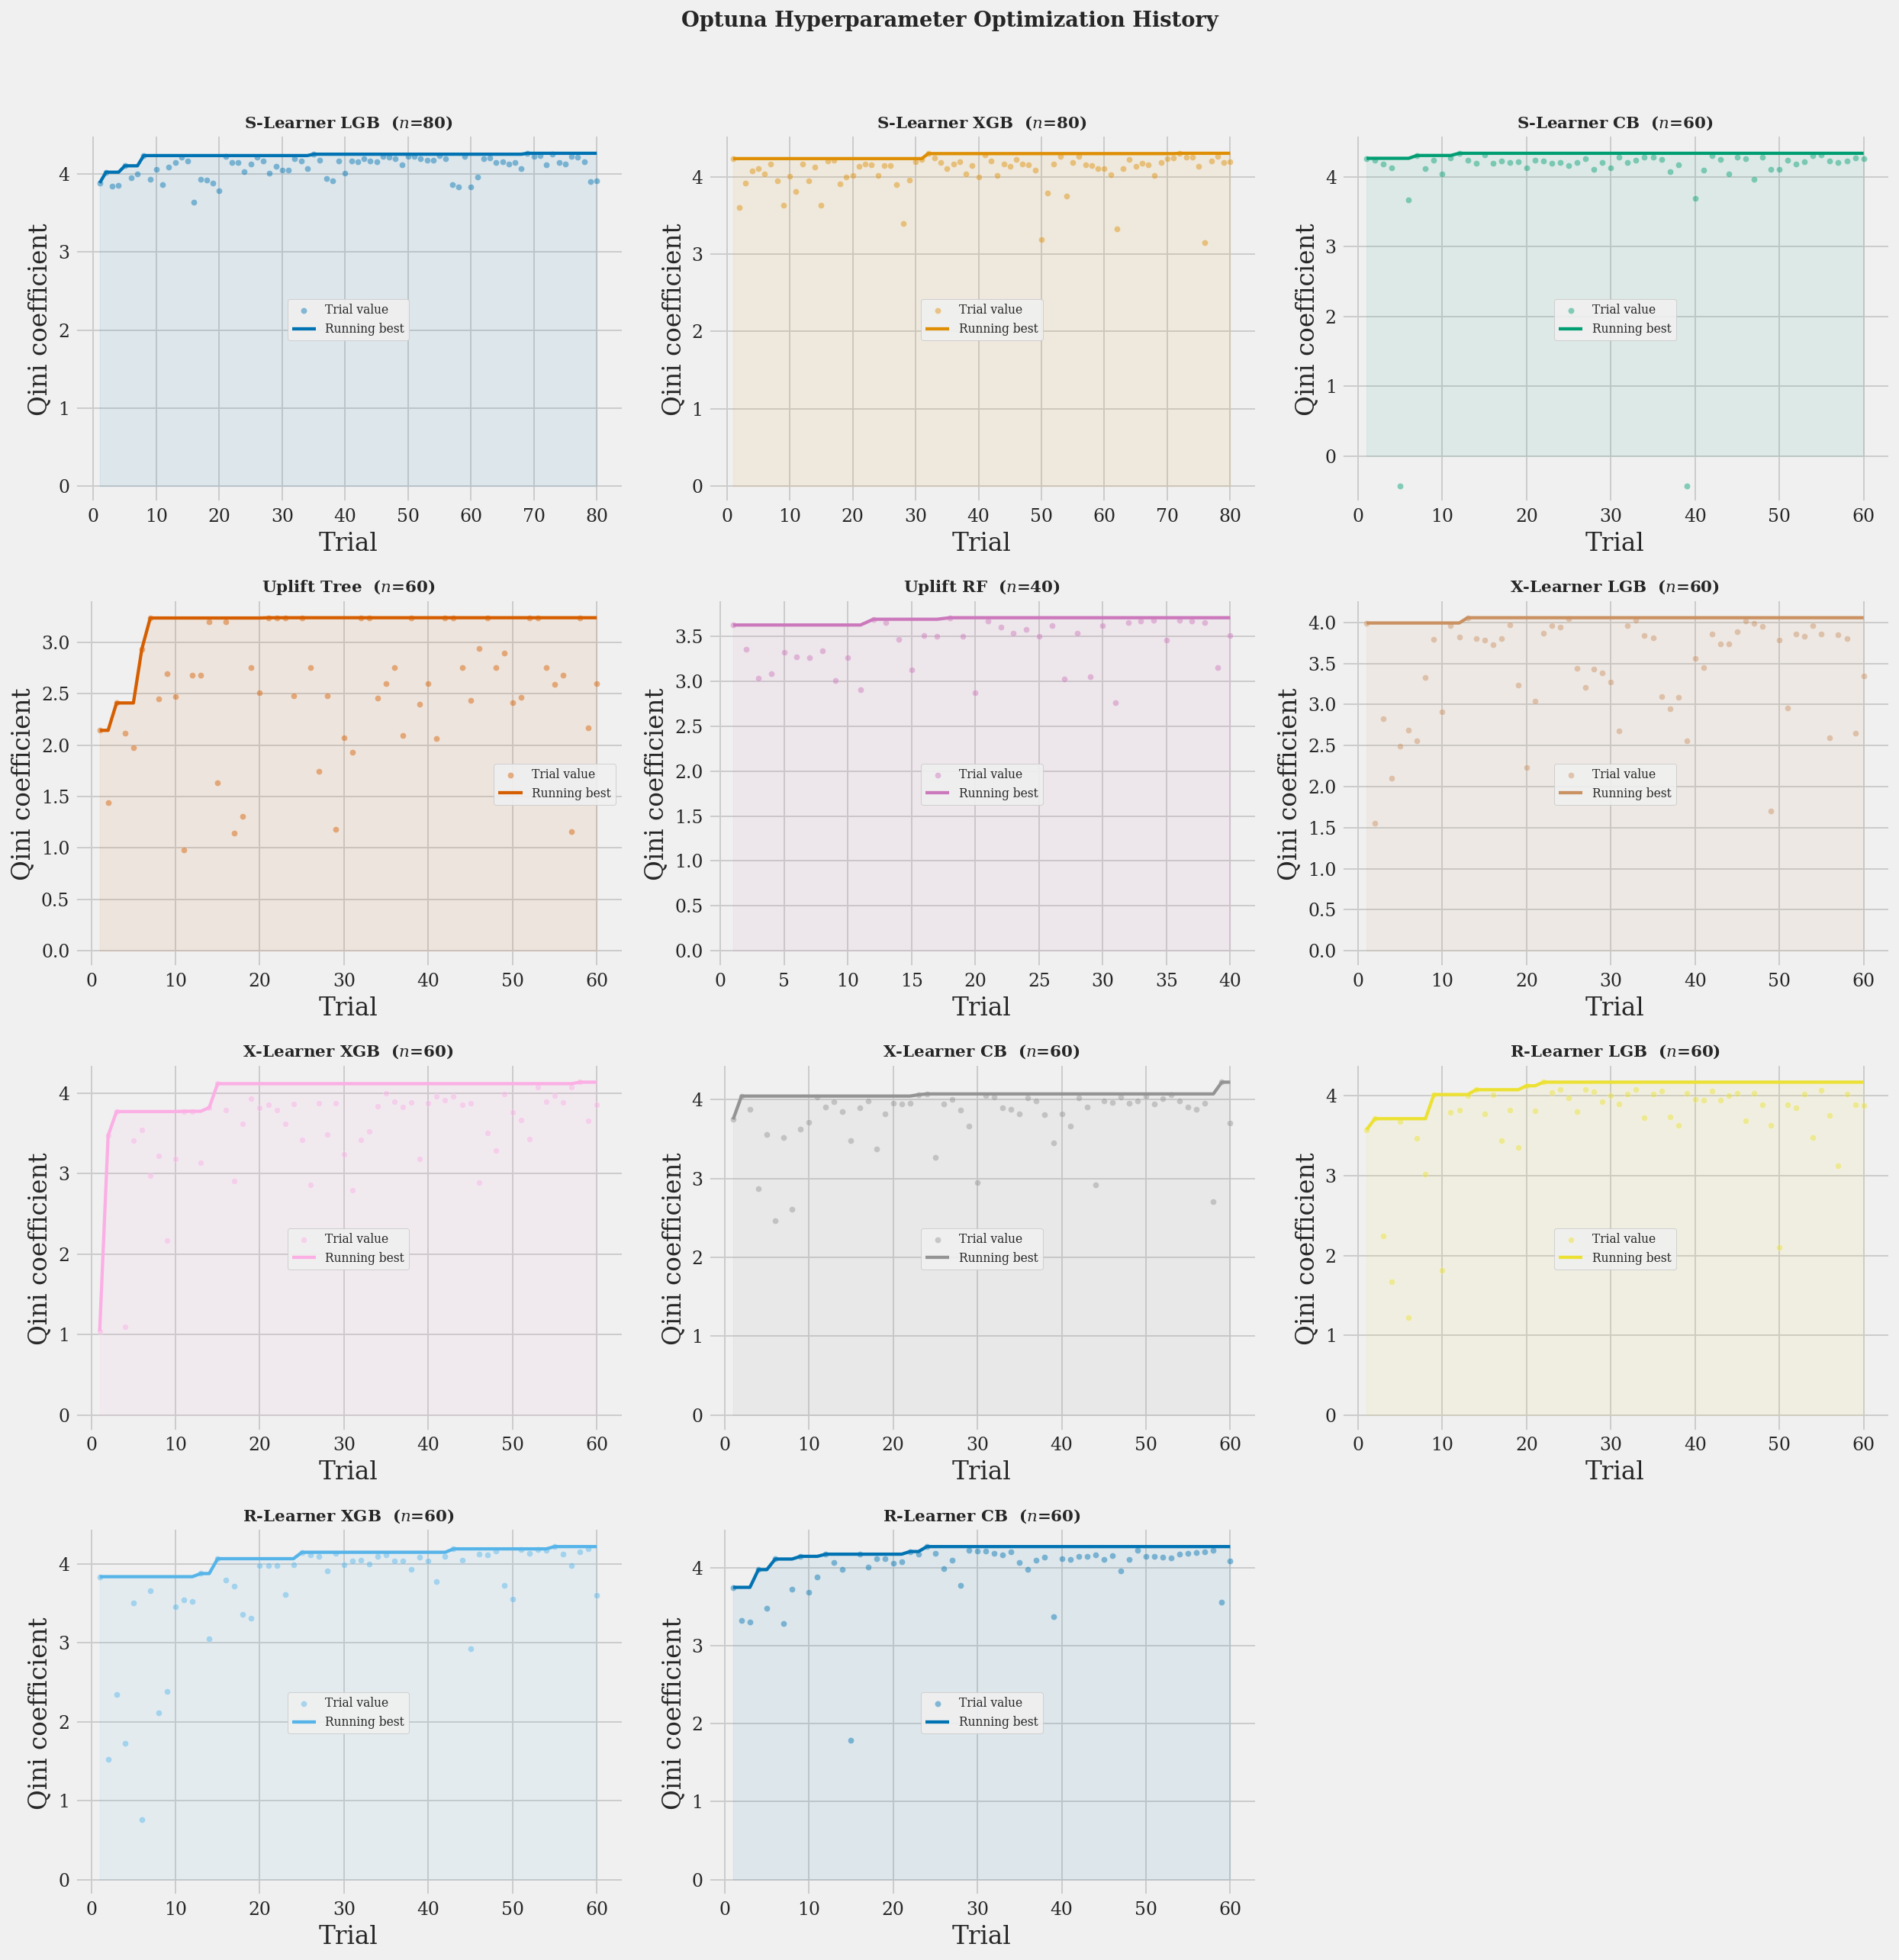

In [24]:
studies_list = [
    ("S-Learner LGB",  study_lgb),
    ("S-Learner XGB",  study_xgb),
    ("S-Learner CB",   study_cb),
    ("Uplift Tree",    study_utree),
    ("Uplift RF",      study_urf),
    ("X-Learner LGB",  study_xlearner),
    ("X-Learner XGB",  study_xlearner_xgb),
    ("X-Learner CB",   study_xlearner_cb),
    ("R-Learner LGB",  study_rlearner),
    ("R-Learner XGB",  study_rlearner_xgb),
    ("R-Learner CB",   study_rlearner_cb),
]

n_studies = len(studies_list)
n_cols = min(n_studies, 3)
n_rows = (n_studies + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
axes_flat = np.array(axes).flatten()

for idx, (name, study) in enumerate(studies_list):
    ax = axes_flat[idx]
    vals = [t.value for t in study.trials if t.value is not None]
    best_so_far = pd.Series(vals).cummax()
    trials_x = np.arange(1, len(vals) + 1)

    ax.scatter(trials_x, vals, s=18, alpha=0.45, color=PALETTE[idx % len(PALETTE)],
               edgecolors="white", linewidth=0.3, zorder=3, label="Trial value")
    ax.plot(trials_x, best_so_far.values, color=PALETTE[idx % len(PALETTE)],
            linewidth=2.2, zorder=4, label="Running best")
    ax.fill_between(trials_x, best_so_far.values, alpha=0.08,
                    color=PALETTE[idx % len(PALETTE)])

    ax.set_title(f"{name}  ($n$={len(vals)})", fontweight="bold", fontsize=11)
    ax.set_xlabel("Trial")
    ax.set_ylabel("Qini coefficient")
    ax.legend(fontsize=8, framealpha=0.9)
    sns.despine(ax=ax)

# hide unused axes
for j in range(n_studies, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Optuna Hyperparameter Optimization History",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Comprehensive Model Comparison

,Qini Coeff.,Uplift@30%,Mean CATE,Median CATE,Std CATE,% Positive,Optuna Trials
Model,,,,,,,
S-Learner LightGBM,+4.263827,+17.23,-1.8457,-2.2642,9.5546,41.8%,80
S-Learner XGBoost,+4.302881,+17.60,-2.1162,-2.9564,10.5039,39.8%,80
S-Learner CatBoost,+4.335771,+17.05,-1.8701,-2.7245,9.8192,43.4%,60
Uplift Decision Tree,+3.239938,+13.57,+0.0461,+0.0488,0.0219,100.0%,60
Uplift Random Forest,+3.710408,+13.58,+0.0460,+0.0347,0.0189,100.0%,40
X-Learner LightGBM,+3.988810,+15.83,-2.3168,-1.1370,15.0988,47.4%,60
X-Learner XGBoost,+4.138642,+17.46,-2.3262,-1.1361,15.1906,47.3%,60
X-Learner CatBoost,+4.222602,+17.53,-2.3106,-1.0534,14.7828,47.6%,60
R-Learner LightGBM,+4.081096,+16.54,-2.3772,-2.2330,14.6264,45.6%,60


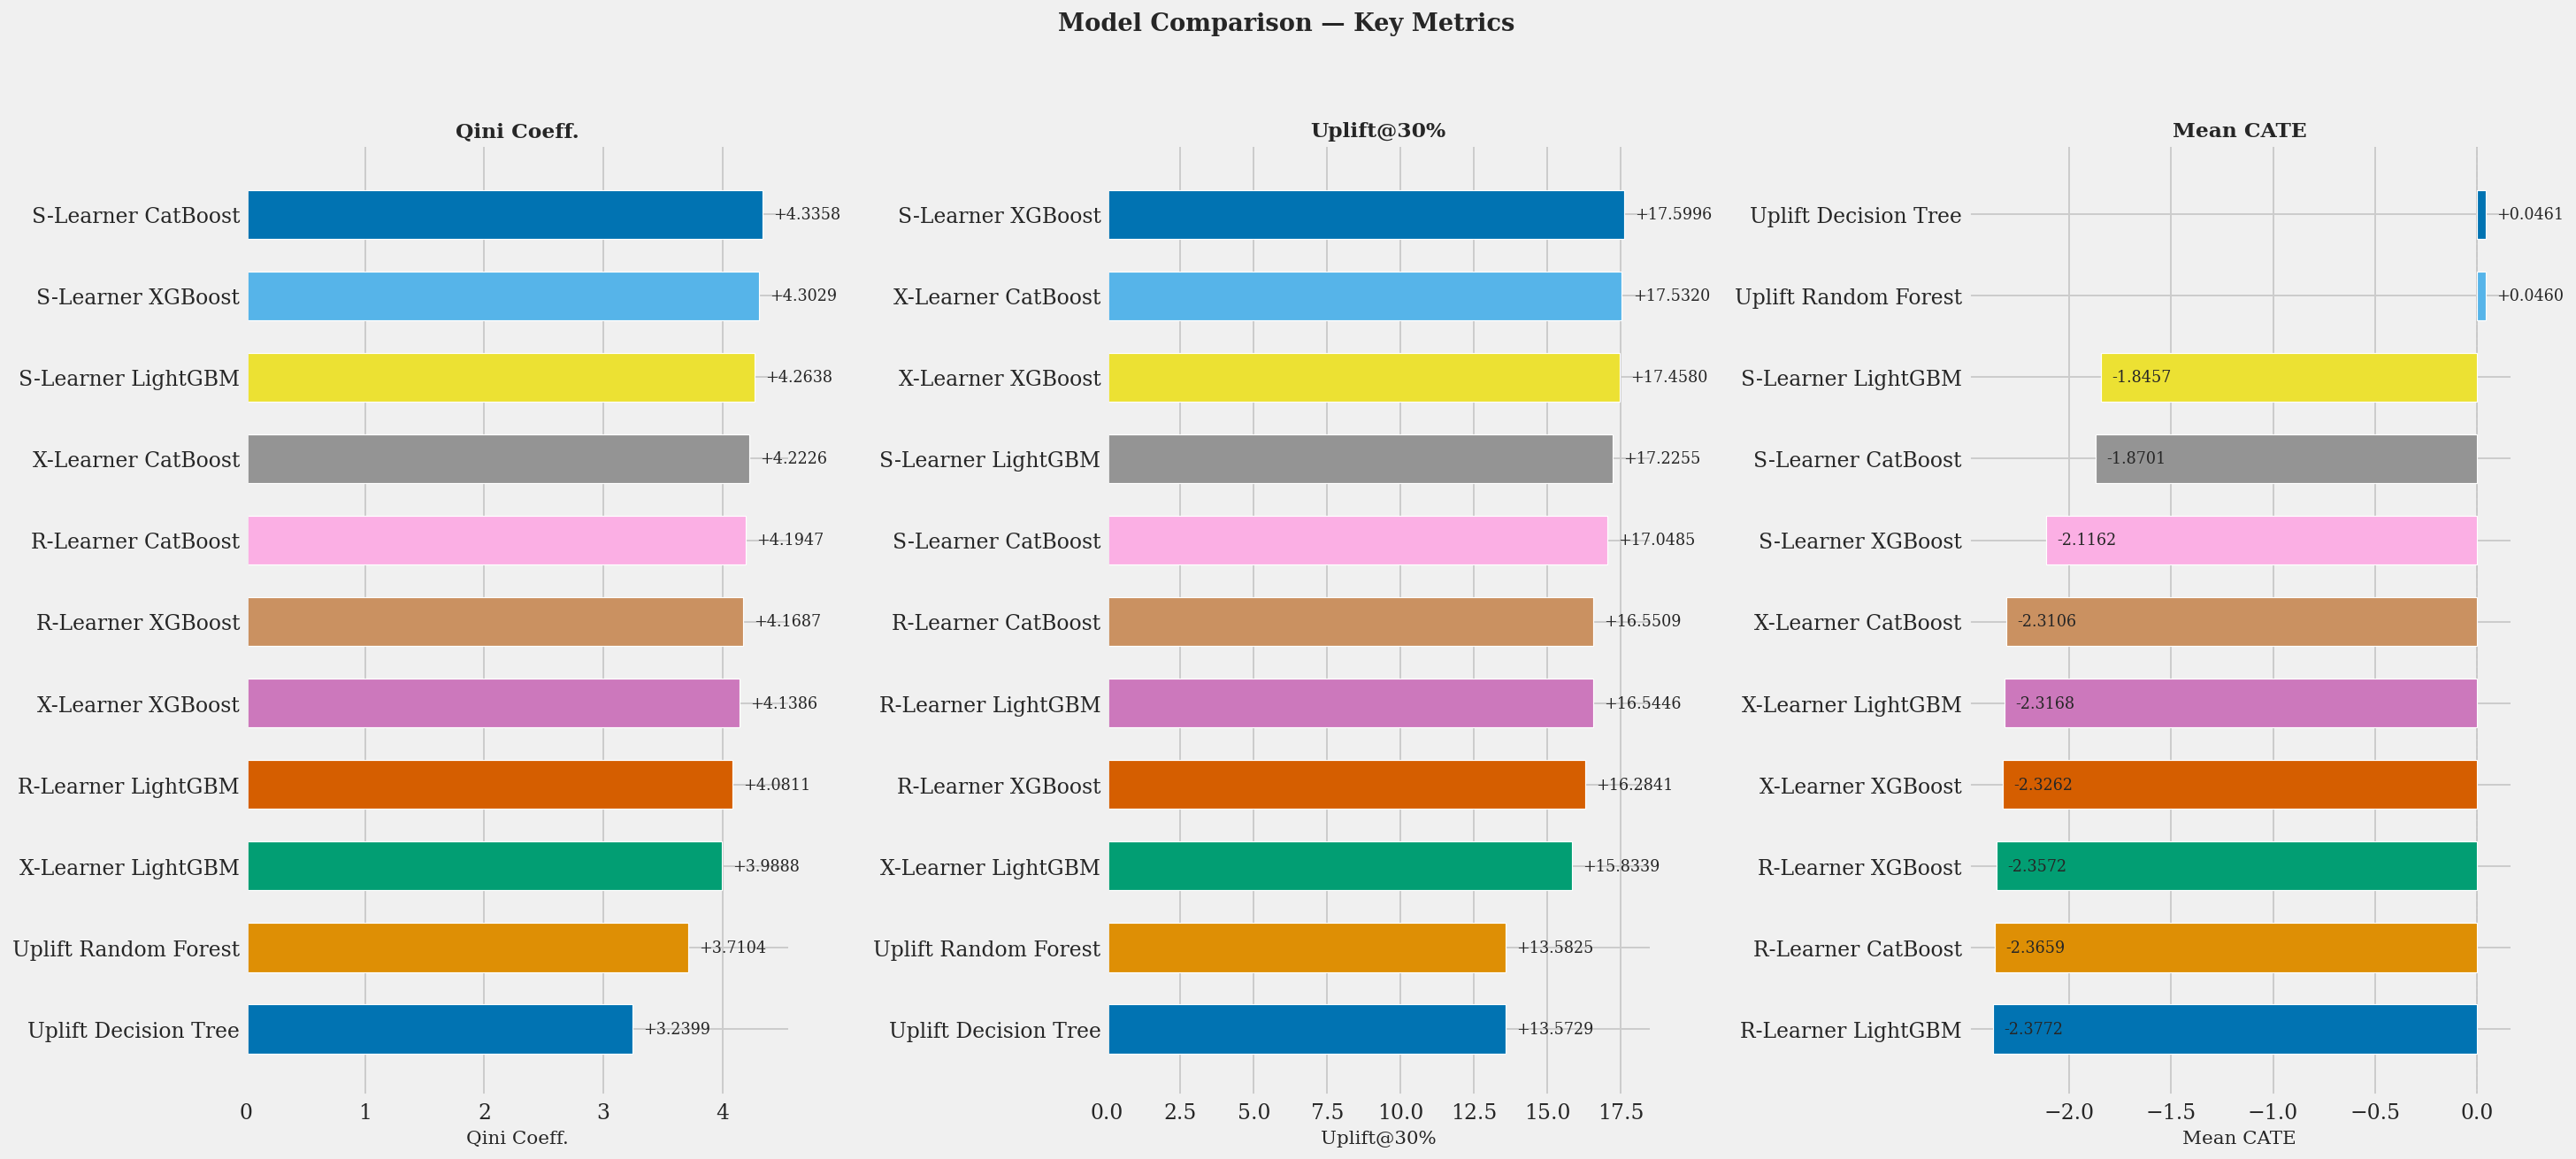

In [25]:
# ---- Summary table ---------------------------------------------------
summary_rows = []
for name, res in results.items():
    vd = res["val_data"]
    summary_rows.append({
        "Model": name,
        "Qini Coeff.": res["qini"],
        "Uplift@30%": res["uplift_30"],
        "Mean CATE": vd["uplift_score"].mean(),
        "Median CATE": vd["uplift_score"].median(),
        "Std CATE": vd["uplift_score"].std(),
        "% Positive": (vd["uplift_score"] > 0).mean() * 100,
        "Optuna Trials": len(res["study"].trials),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model")
display(summary_df.style.format({
    "Qini Coeff.": "{:+.6f}", "Uplift@30%": "{:+.2f}",
    "Mean CATE": "{:+.4f}", "Median CATE": "{:+.4f}",
    "Std CATE": "{:.4f}", "% Positive": "{:.1f}%",
    "Optuna Trials": "{:.0f}",
}).background_gradient(subset=["Qini Coeff.", "Uplift@30%"], cmap="RdYlGn"))

# ---- Bar charts ------------------------------------------------------
metrics_to_plot = ["Qini Coeff.", "Uplift@30%", "Mean CATE"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(7 * len(metrics_to_plot), 0.6 * len(summary_df) + 2.5))

for ax, metric in zip(axes, metrics_to_plot):
    vals = summary_df[metric].sort_values()
    colors_bar = [PALETTE[i % len(PALETTE)] for i in range(len(vals))]
    bars = ax.barh(vals.index, vals.values, color=colors_bar, edgecolor="white",
                   linewidth=0.6, height=0.6)
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(metric, fontweight="bold", fontsize=12)
    for bar, v in zip(bars, vals.values):
        offset = abs(ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.02
        ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height() / 2,
                f"{v:+.4f}", va="center", fontsize=9, fontweight="medium")
    ax.axvline(0, color="0.4", linewidth=0.8, linestyle="--", zorder=0)
    sns.despine(ax=ax)

plt.suptitle("Model Comparison \u2014 Key Metrics",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## Uplift Score Distributions

Histograms of predicted CATE for each model. The red dashed line marks the selection threshold (CATE=0).

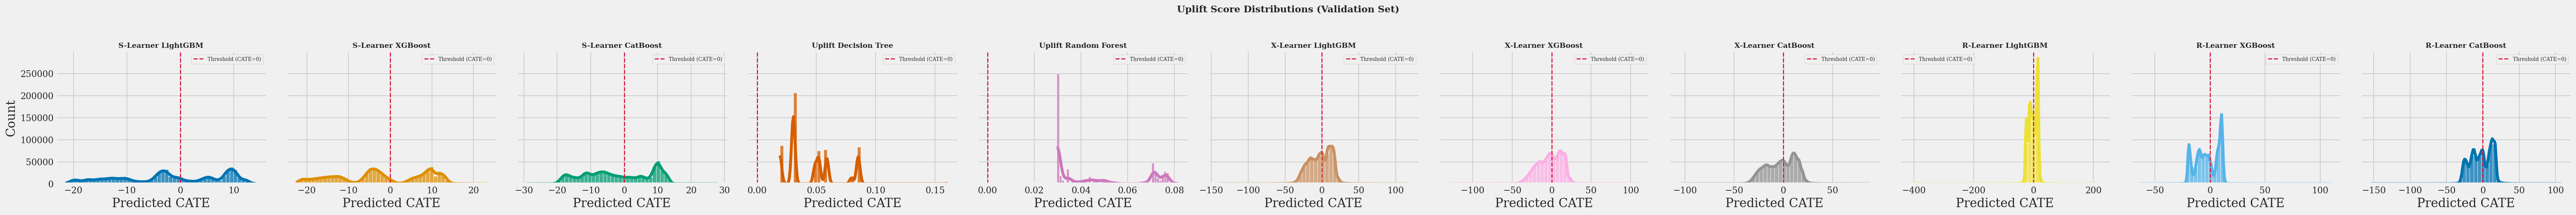

In [26]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(4.5 * n_models, 4), sharey=True)
if n_models == 1:
    axes = [axes]

for idx, (ax, (name, res)) in enumerate(zip(axes, results.items())):
    scores = res["val_data"]["uplift_score"]
    sns.histplot(scores, bins=50, kde=True, color=PALETTE[idx % len(PALETTE)],
                 edgecolor="white", linewidth=0.4, alpha=0.75, ax=ax)
    ax.axvline(0, color="crimson", linestyle="--", linewidth=1.5, label="Threshold (CATE=0)")
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted CATE")
    ax.legend(fontsize=7, framealpha=0.9)
    sns.despine(ax=ax)

axes[0].set_ylabel("Count")
plt.suptitle("Uplift Score Distributions (Validation Set)",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## Qini Curves

The Qini curve plots cumulative uplift as we target more and more customers (sorted by predicted CATE descending). Models whose curves stay above the random diagonal are doing useful work.

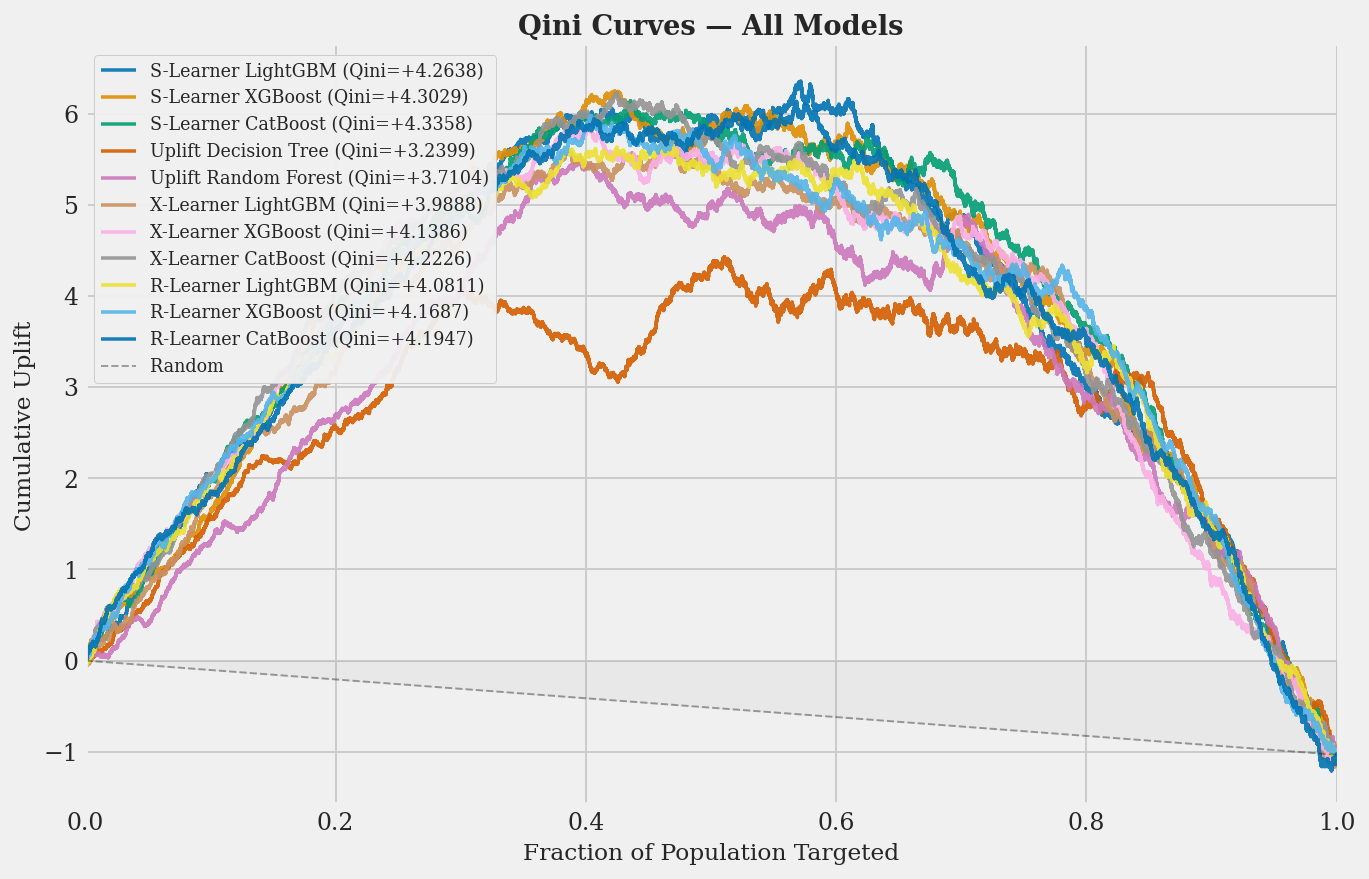

In [27]:
fig, ax = plt.subplots(figsize=(10, 6.5))

for idx, (name, res) in enumerate(results.items()):
    vd = res["val_data"].sort_values("uplift_score", ascending=False).reset_index(drop=True)
    y_s = vd[col_target].values.astype(float)
    w_s = vd[col_treatment].values.astype(float)

    n_t = w_s.sum()
    n_c = len(w_s) - n_t

    cum_t = np.cumsum(y_s * w_s) / n_t
    cum_c = np.cumsum(y_s * (1 - w_s)) / n_c
    qini = cum_t - cum_c
    frac = np.arange(1, len(qini) + 1) / len(qini)

    ax.plot(frac, qini, label=f"{name} (Qini={res['qini']:+.4f})",
            color=PALETTE[idx % len(PALETTE)], linewidth=1.8, alpha=0.9)

# Random baseline
ax.plot([0, 1], [0, qini[-1]], "k--", alpha=0.4, linewidth=1, label="Random")
ax.fill_between([0, 1], 0, [0, qini[-1]], alpha=0.03, color="black")

ax.set_xlabel("Fraction of Population Targeted", fontsize=12)
ax.set_ylabel("Cumulative Uplift", fontsize=12)
ax.set_title("Qini Curves \u2014 All Models", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=9, framealpha=0.95, edgecolor="0.8")
ax.set_xlim(0, 1)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## Feature Importance (Gradient Boosting Models)

Top-15 features by importance for each S-Learner base model. The `_treatment` feature shows how much the model relies on the treatment indicator.

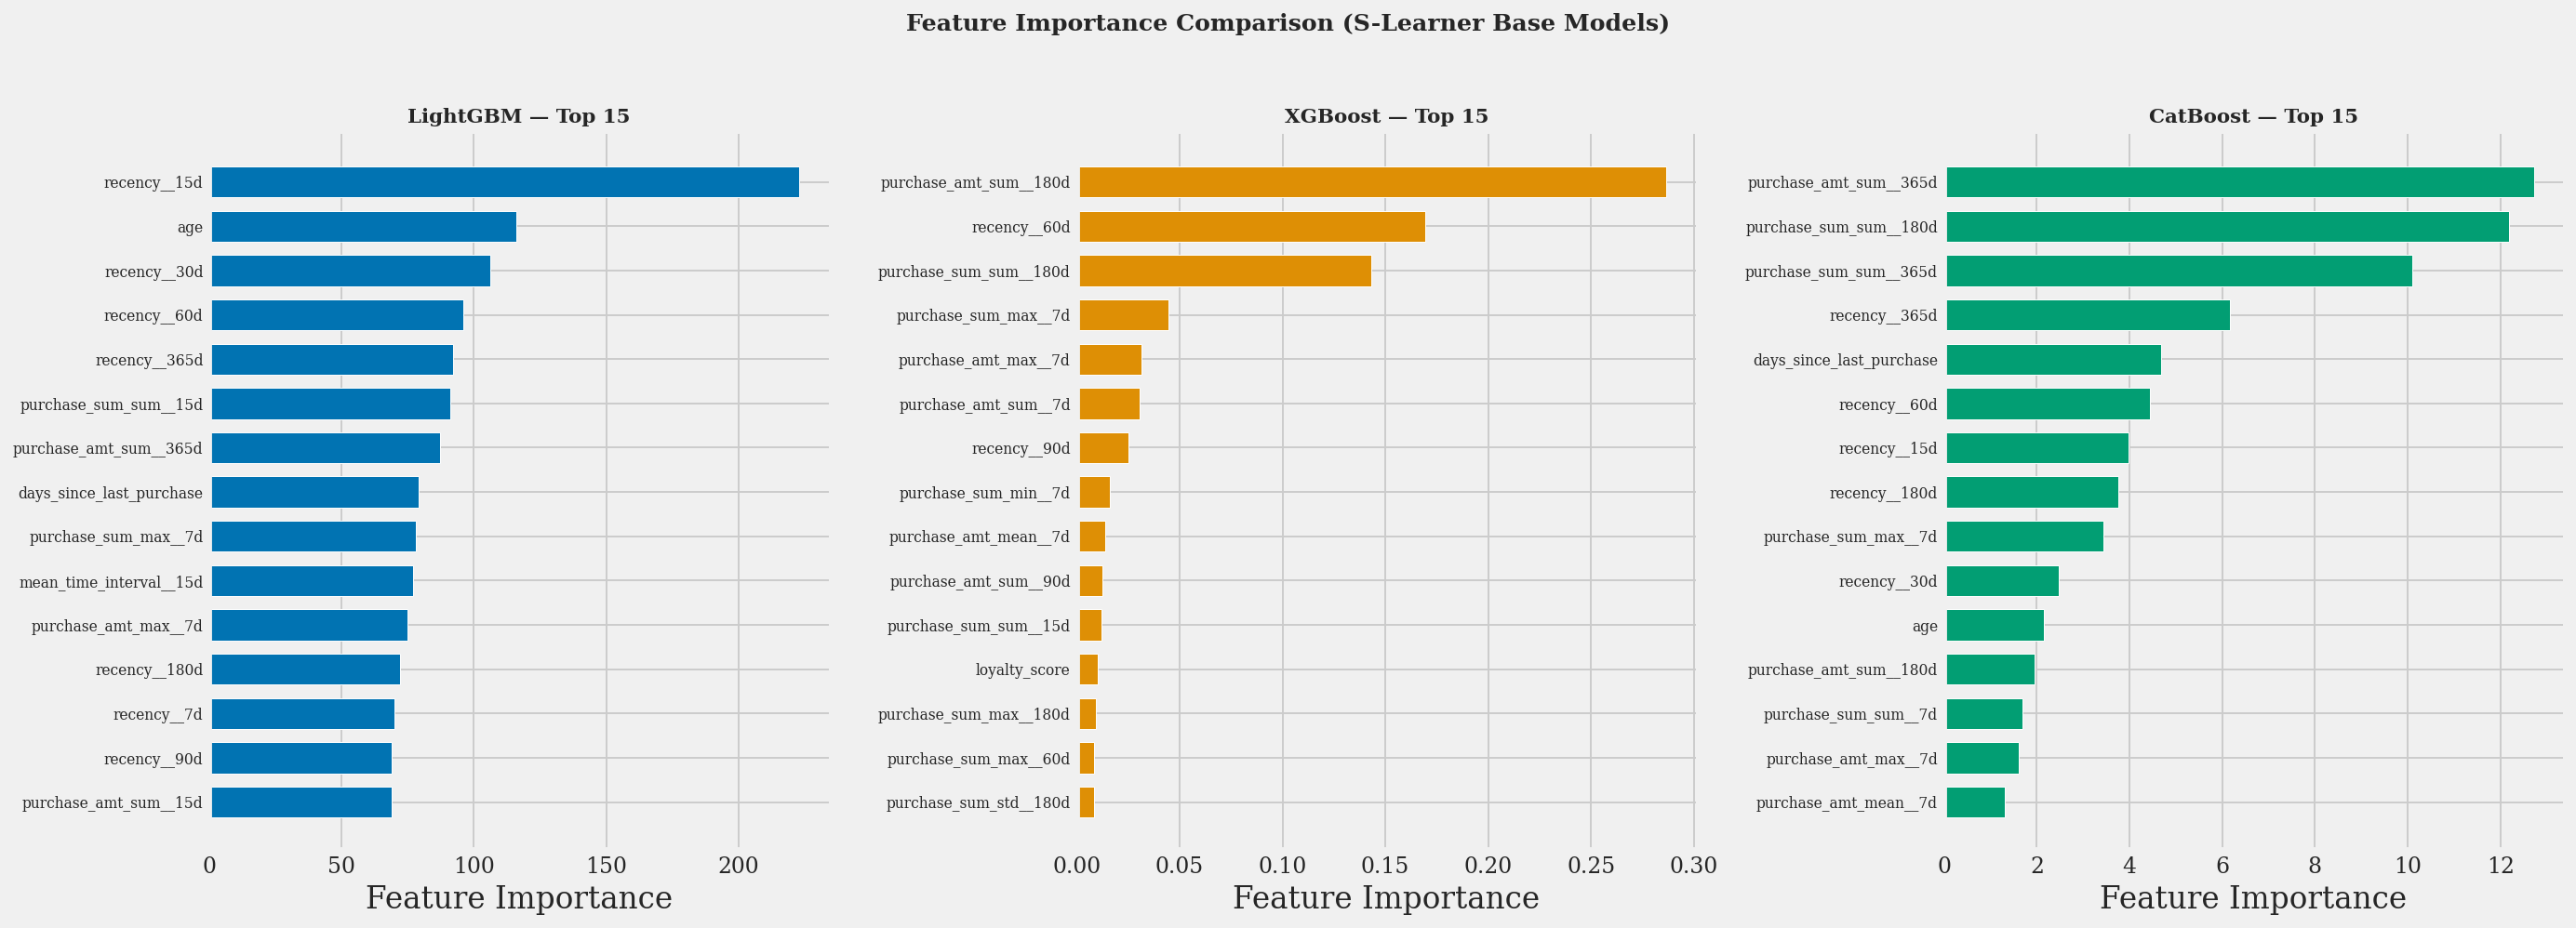

In [28]:
gb_models = {
    "LightGBM": final_lgb,
    "XGBoost":  final_xgb,
    "CatBoost": final_cb,
}
cols_with_t = cols_features + ["_treatment"]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for idx, (ax, (name, mdl)) in enumerate(zip(axes, gb_models.items())):
    if hasattr(mdl, "feature_importances_"):
        imp = mdl.feature_importances_
        top_idx = np.argsort(imp)[-15:]
        top_names = [cols_with_t[i] for i in top_idx]
        top_vals = imp[top_idx]

        bars = ax.barh(range(len(top_idx)), top_vals,
                       color=PALETTE[idx % len(PALETTE)], edgecolor="white",
                       linewidth=0.5, height=0.7)
        ax.set_yticks(range(len(top_idx)))
        ax.set_yticklabels(top_names, fontsize=8)
        ax.set_title(f"{name} \u2014 Top 15", fontweight="bold", fontsize=11)
        ax.set_xlabel("Feature Importance")
        sns.despine(ax=ax)

plt.suptitle("Feature Importance Comparison (S-Learner Base Models)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Select Best Model + MLflow Model Registry

Pick the model with the highest Qini coefficient and register it in the MLflow Model Registry for serving.

In [29]:
best_name = max(results, key=lambda k: results[k]["qini"])
best = results[best_name]
best_model = best["model"]
best_run = best["run"]

print(f"Best model:  {best_name}")
print(f"Qini coeff:  {best['qini']:+.6f}")
print(f"Uplift@30%:  {best['uplift_30']:+.2f}")
print(f"MLflow run:  {best_run.info.run_id}")

# Register in MLflow Model Registry
model_uri = f"runs:/{best_run.info.run_id}/uplift_model"
registered = mlflow.register_model(model_uri, "smart-reach-uplift-model")

print(f"\nRegistered model: {registered.name}")
print(f"Version:          {registered.version}")
print(f"Source:           {registered.source}")

Registered model 'smart-reach-uplift-model' already exists. Creating a new version of this model...
2026/04/05 05:53:22 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: smart-reach-uplift-model, version 2


Best model:  S-Learner CatBoost
Qini coeff:  +4.335771
Uplift@30%:  +17.05
MLflow run:  4e5d7dc2ce764a32a3406f750ec329c6

Registered model: smart-reach-uplift-model
Version:          2
Source:           mlflow-artifacts:/891771547198046922/4e5d7dc2ce764a32a3406f750ec329c6/artifacts/uplift_model


Created version '2' of model 'smart-reach-uplift-model'.


## Save Artifacts for Serving

Save the transform pipeline, best model, and extract config so the campaign flow can use them.

In [30]:
ARTIFACTS_DIR = os.path.abspath("../artifacts")
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# 1. Transform pipeline
with open(os.path.join(ARTIFACTS_DIR, "serving_transform_pipeline.pickle"), "wb") as f:
    pickle.dump(transform_pipeline, f)

# 2. Best model bundle
mk = ModelKeeper(model=best_model, column_set=cols_features)
mk.dump(os.path.join(ARTIFACTS_DIR, "uplift_model.pickle"))

# 3. Extract config (same as serving)
serving_extract = [
    {"name": "receipts_agg",     "args": {"delta": 7}},
    {"name": "receipts_agg",     "args": {"delta": 15}},
    {"name": "receipts_agg",     "args": {"delta": 30}},
    {"name": "receipts_agg",     "args": {"delta": 60}},
    {"name": "receipts_agg",     "args": {"delta": 90}},
    {"name": "receipts_agg",     "args": {"delta": 180}},
    {"name": "receipts_agg",     "args": {"delta": 365}},
    {"name": "recency_global",   "args": {}},
    {"name": "purchase_trend",   "args": {"delta_short": 7,  "delta_long": 30}},
    {"name": "purchase_trend",   "args": {"delta_short": 15, "delta_long": 60}},
    {"name": "purchase_trend",   "args": {"delta_short": 30, "delta_long": 120}},
    {"name": "purchase_trend",   "args": {"delta_short": 30, "delta_long": 365}},
    {"name": "purchase_trend",   "args": {"delta_short": 90, "delta_long": 365}},
    {"name": "demographics",     "args": {}},
    {"name": "campaign_history", "args": {}},
    {"name": "day_of_week",      "args": {}},
    {"name": "avg_city_cheque",  "args": {}},
    {"name": "loyalty",          "args": {}},
]
with open(os.path.join(ARTIFACTS_DIR, "serving_extract_config.json"), "w") as f:
    json.dump(serving_extract, f, indent=2)

print("Artifacts saved:")
for fn in sorted(os.listdir(ARTIFACTS_DIR)):
    print(f"  {fn}")

Artifacts saved:
  serving_extract_config.json
  serving_transform_pipeline.pickle
  uplift_model.pickle


## Generate Submission (Full Dataset Scoring)

Score ALL customers with the best model, compute expected net profit per customer accounting for COST_PER_GRAM, CONTACT_COST, MARGIN_PER_GRAM, and DISCOUNT_USD. Only select customers where targeting is profitable.

Selected 867,292 / 2,000,000  (43.4%) customers
Expected total net profit (summed CATE): 6,926,932 dollars
Saved to c:\Work And Studies\Important Things\Scholarly Pursuits\Hard ML\Uplift Modeling\uplift_modeling_setup\runs\submission.csv


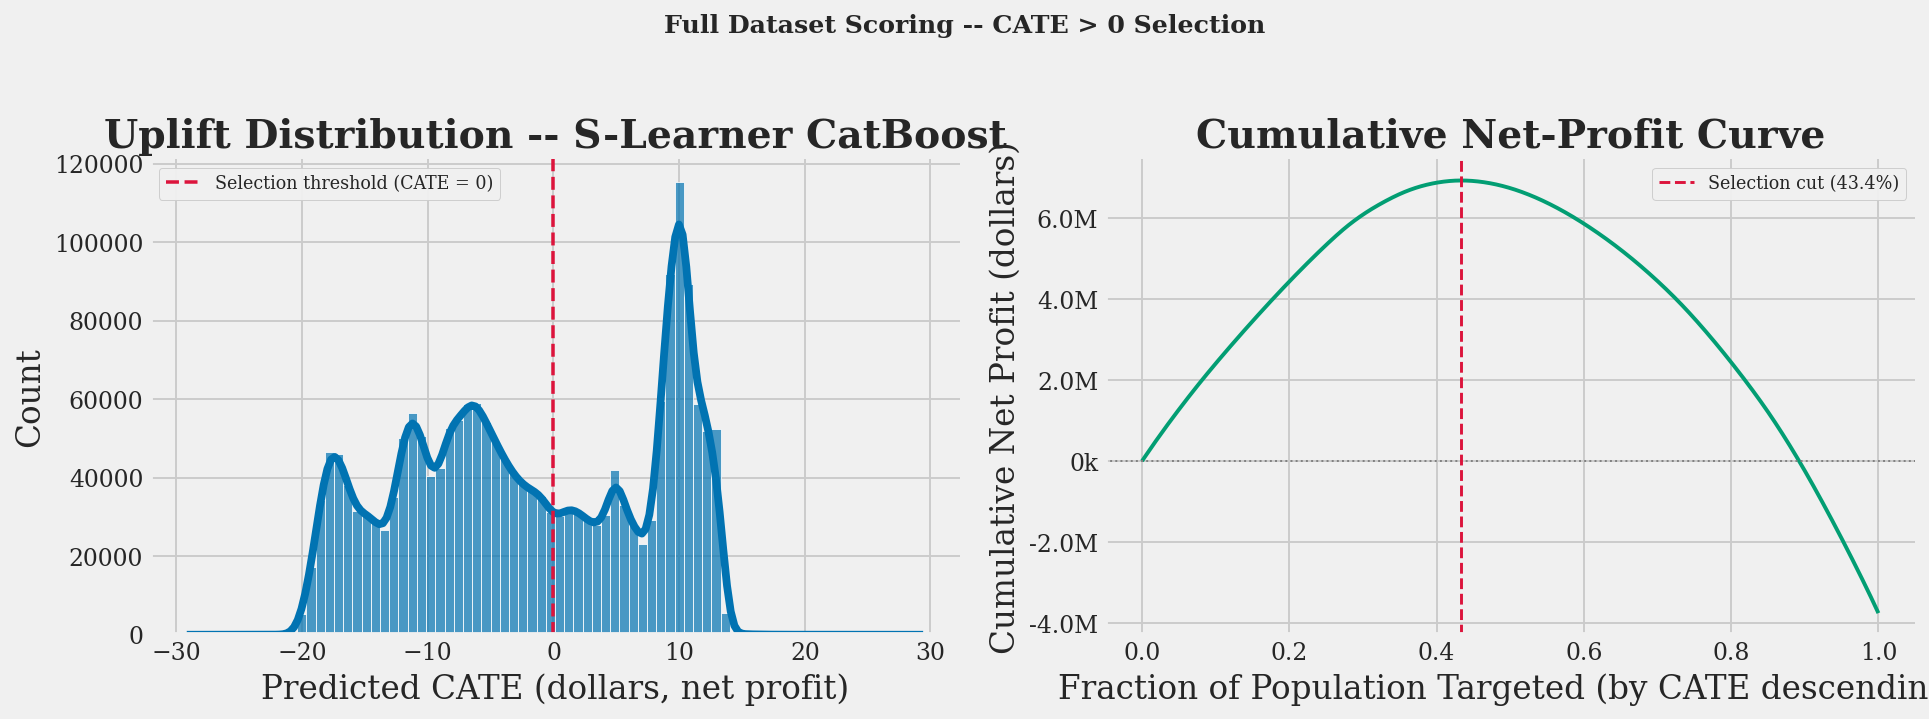

In [31]:
all_features = extract_features(engine, extract_config)
all_features = transform_pipeline.transform(all_features)

preds_all = best_model.predict(all_features[cols_features].values)
if preds_all.ndim == 2:
    preds_all = preds_all[:, 0]
all_features["uplift_score"] = preds_all

# The model was trained on target_profit (costs already baked in).
# CATE is therefore in net-profit units (dollars).
# Selection rule: CATE > 0  <=>  expected incremental profit > 0.
# Applying the cost formula again would double-count -- do not do it.
selected   = all_features.loc[all_features["uplift_score"] > 0, "customer_id"]
n_total    = len(all_features)
n_sel      = len(selected)
exp_profit = all_features.loc[all_features["uplift_score"] > 0, "uplift_score"].sum()

print(f"Selected {n_sel:,} / {n_total:,}  ({n_sel/n_total:.1%}) customers")
print(f"Expected total net profit (summed CATE): {exp_profit:,.0f} dollars")

output_path = os.path.abspath("../runs/submission.csv")
os.makedirs(os.path.dirname(output_path), exist_ok=True)
selected.to_frame().to_csv(output_path, index=False)
print(f"Saved to {output_path}")

# -- Distribution plots --
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CATE distribution (net-profit units, dollars)
sns.histplot(preds_all, bins=80, kde=True, color=PALETTE[0],
             edgecolor="white", linewidth=0.4, alpha=0.7, ax=axes[0])
axes[0].axvline(0, color="crimson", linestyle="--", linewidth=1.8,
                label="Selection threshold (CATE = 0)")
axes[0].set_xlabel("Predicted CATE (dollars, net profit)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Uplift Distribution -- {best_name}", fontweight="bold")
axes[0].legend(fontsize=9, framealpha=0.95)
sns.despine(ax=axes[0])

# Right: cumulative net-profit curve (sort descending by CATE)
sorted_cate = np.sort(preds_all)[::-1]
cum_profit  = np.cumsum(sorted_cate)
frac        = np.linspace(0, 1, len(sorted_cate))

axes[1].plot(frac, cum_profit, color=PALETTE[2], linewidth=2)
axes[1].axhline(0, color="0.5", linestyle=":", linewidth=1)
axes[1].axvline(n_sel / n_total, color="crimson", linestyle="--", linewidth=1.5,
                label=f"Selection cut ({n_sel/n_total:.1%})")
axes[1].set_xlabel("Fraction of Population Targeted (by CATE descending)")
axes[1].set_ylabel("Cumulative Net Profit (dollars)")
axes[1].set_title("Cumulative Net-Profit Curve", fontweight="bold")
axes[1].legend(fontsize=9, framealpha=0.95)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if abs(x) >= 1e6 else f"{x/1e3:.0f}k"))
sns.despine(ax=axes[1])

plt.suptitle("Full Dataset Scoring -- CATE > 0 Selection",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()
